# VizWiz VQA Model Training - No Attention Mechanism

Notebook để huấn luyện mô hình Visual Question Answering (VQA) trên dataset VizWiz **KHÔNG SỬ DỤNG ATTENTION MECHANISM**. 

Điểm khác biệt chính với mô hình có attention:
- **No Attention**: Sử dụng global average pooling thay vì attention mechanism
- **Simpler Architecture**: Ít tham số hơn, training nhanh hơn  
- **Baseline Performance**: Để so sánh với mô hình có attention

Dữ liệu đã được tiền xử lý sẵn, chỉ cần training và evaluation.

## 1. Import Required Libraries and Load Configuration

In [6]:
import os
import sys
import json
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.autograd import Variable
from tqdm import tqdm
from datetime import datetime
import numpy as np
import h5py
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Add project path to sys.path
project_path = './VizWiz-VQA-PyTorch-master'
if project_path not in sys.path:
    sys.path.append(project_path)

print("🚀 Khởi tạo VQA No-Attention Model Training")
print("=" * 60)

# Check if required files exist
required_files = [
    './VizWiz-VQA-PyTorch-master/models.py',
    './VizWiz-VQA-PyTorch-master/utils.py',
    './VizWiz-VQA-PyTorch-master/datasets/vqa_dataset.py'
]

print("🔍 Checking required project files...")
all_files_found = True
for file_path in required_files:
    if os.path.exists(file_path):
        print(f"  ✅ {os.path.basename(file_path)}")
    else:
        print(f"  ❌ {os.path.basename(file_path)} - NOT FOUND!")
        all_files_found = False

if not all_files_found:
    raise FileNotFoundError("Some required project files are missing!")

# Import project modules
try:
    import models
    import utils
    from datasets import vqa_dataset
    print("✅ All project modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    raise

# Load config from YAML file
config_path = './VizWiz-VQA-PyTorch-master/config/default.yaml'
with open(config_path, 'r') as handle:
    config = yaml.load(handle, Loader=yaml.FullLoader)

print(f"\n📋 Original configuration loaded from: {config_path}")

# Update paths for Windows and existing directory structure
config['annotations']['dir'] = './data/Annotations'
config['images']['dir'] = './data'
config['annotations']['path_vocabs'] = './prepro_data/vocabs.json'
config['images']['path_features'] = './prepro_data/resnet14x14.h5'

# 🔥 KEY CHANGE: Set attention to 'none' for no-attention model
config['images']['mode'] = 'noatt'  # Use no-attention features
config['model']['attention']['glimpses'] = 0  # Disable attention glimpses

print(f"\n🔧 MODIFIED CONFIG FOR NO-ATTENTION MODEL:")
print(f"  🎯 Image mode: {config['images']['mode']} (no attention)")
print(f"  🎯 Attention glimpses: {config['model']['attention']['glimpses']}")

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔥 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Create logs directory
log_dir = './logs/vizwiz_noattention'
os.makedirs(log_dir, exist_ok=True)
print(f"📁 Logs directory: {log_dir}")

print("\n" + "=" * 60)
print("✅ Configuration setup completed!")
print("=" * 60)

🚀 Khởi tạo VQA No-Attention Model Training
🔍 Checking required project files...
  ✅ models.py
  ✅ utils.py
  ✅ vqa_dataset.py
✅ All project modules imported successfully

📋 Original configuration loaded from: ./VizWiz-VQA-PyTorch-master/config/default.yaml

🔧 MODIFIED CONFIG FOR NO-ATTENTION MODEL:
  🎯 Image mode: noatt (no attention)
  🎯 Attention glimpses: 0

🔥 Device: cuda
   GPU: Quadro P1000
   CUDA Memory: 4.3 GB
📁 Logs directory: ./logs/vizwiz_noattention

✅ Configuration setup completed!


## 2. Verify Pre-processed Data and Setup Paths

In [7]:
# Verify all required data files exist and are accessible
required_data_files = [
    config['annotations']['path_vocabs'],           # vocabs.json
    config['images']['path_features'],              # resnet14x14.h5  
    config['annotations']['dir'] + '/train.json',  # training annotations
    config['annotations']['dir'] + '/val.json',    # validation annotations
    config['annotations']['dir'] + '/test.json'    # test annotations (optional)
]

print("🔍 Verifying pre-processed data files...")
print("=" * 50)

data_status = {}
for file_path in required_data_files:
    file_name = os.path.basename(file_path)
    
    if os.path.exists(file_path):
        file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
        data_status[file_name] = True
        print(f"✅ {file_name:<20} ({file_size_mb:.1f} MB)")
        
        # Check specific file contents
        if file_path.endswith('.h5'):
            # Check HDF5 features file
            try:
                with h5py.File(file_path, 'r') as f:
                    print(f"    📊 HDF5 keys: {list(f.keys())}")
                    if 'noatt' in f:
                        print(f"    🎯 No-attention features: {f['noatt'].shape}")
                    if 'att' in f:
                        print(f"    👁️ Attention features: {f['att'].shape}")
                    if 'image' in f:
                        print(f"    🖼️ Image names: {len(f['image'])} images")
            except Exception as e:
                print(f"    ⚠️ Error reading HDF5: {e}")
                
        elif 'vocabs' in file_path:
            # Check vocabulary file
            try:
                with open(file_path, 'r') as f:
                    vocabs = json.load(f)
                    print(f"    📖 Question vocab: {len(vocabs['question']):,} tokens")
                    print(f"    📝 Answer vocab: {len(vocabs['answer']):,} answers")
            except Exception as e:
                print(f"    ⚠️ Error reading vocabs: {e}")
                
        elif file_path.endswith('.json') and 'Annotations' in file_path:
            # Check annotation files
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    annotations = json.load(f)
                    print(f"    📋 Annotations: {len(annotations):,} samples")
                    
                    # Show sample annotation structure
                    if annotations:
                        sample = annotations[0]
                        print(f"    🔍 Sample keys: {list(sample.keys())}")
            except Exception as e:
                print(f"    ⚠️ Error reading annotations: {e}")
    else:
        data_status[file_name] = False
        print(f"❌ {file_name:<20} - NOT FOUND!")

# Summary
missing_files = [name for name, exists in data_status.items() if not exists]
if missing_files:
    print(f"\n⚠️ Missing files: {missing_files}")
    if 'test.json' in missing_files:
        print("   📝 Note: test.json is optional for training")
else:
    print(f"\n🎉 All required data files found and verified!")

print("\n" + "=" * 50)
print(f"📊 Dataset Summary:")
print(f"  📂 Annotations: {config['annotations']['dir']}")
print(f"  🖼️ Features: {config['images']['path_features']}")  
print(f"  📖 Vocabularies: {config['annotations']['path_vocabs']}")
print(f"  🎯 Mode: No-Attention (noatt)")
print("=" * 50)

🔍 Verifying pre-processed data files...
✅ vocabs.json          (0.1 MB)
    📖 Question vocab: 3,891 tokens
    📝 Answer vocab: 3,000 answers
✅ resnet14x14.h5       (21758.6 MB)
    📊 HDF5 keys: ['att', 'image', 'noatt']
    🎯 No-attention features: (28273, 2048)
    👁️ Attention features: (28273, 2048, 14, 14)
    🖼️ Image names: 28273 images
✅ train.json           (19.0 MB)
    📋 Annotations: 18,471 samples
    🔍 Sample keys: ['image', 'question', 'answers', 'answer_type', 'answerable']
✅ val.json             (2.1 MB)
    📋 Annotations: 2,052 samples
    🔍 Sample keys: ['image', 'question', 'answers', 'answer_type', 'answerable']
✅ test.json            (4.3 MB)
    📋 Annotations: 4,319 samples
    🔍 Sample keys: ['image', 'question', 'answers', 'answer_type', 'answerable']

🎉 All required data files found and verified!

📊 Dataset Summary:
  📂 Annotations: ./data/Annotations
  🖼️ Features: ./prepro_data/resnet14x14.h5
  📖 Vocabularies: ./prepro_data/vocabs.json
  🎯 Mode: No-Attention (

## 3. Create Data Loaders for Training and Validation

In [8]:
# Create datasets and data loaders for training and validation
print("📊 Creating data loaders for No-Attention model...")
print("=" * 55)

# Initialize datasets - these will use the no-attention features 
print("🔄 Loading training dataset...")
train_dataset = vqa_dataset.VQADataset(config, 'train')

print("🔄 Loading validation dataset...")
val_dataset = vqa_dataset.VQADataset(config, 'val')

# Verify datasets loaded correctly
print(f"\n📈 Training Dataset:")
print(f"  📋 Samples: {len(train_dataset):,}")
print(f"  📖 Question vocab: {len(train_dataset.vocabs['question']):,}")
print(f"  📝 Answer vocab: {len(train_dataset.vocabs['answer']):,}")
print(f"  🔢 Total tokens: {train_dataset.num_tokens:,}")

print(f"\n📊 Validation Dataset:")
print(f"  📋 Samples: {len(val_dataset):,}")
print(f"  📖 Question vocab: {len(val_dataset.vocabs['question']):,}")
print(f"  📝 Answer vocab: {len(val_dataset.vocabs['answer']):,}")

# Verify vocabulary consistency
assert train_dataset.num_tokens == val_dataset.num_tokens, "Vocabulary size mismatch between train and val!"

# Create data loaders with optimized settings for Windows
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=config['training']['batch_size'],
    num_workers=0,  # Set to 0 for Windows compatibility
    shuffle=True,   # Shuffle training data
    pin_memory=torch.cuda.is_available(),
    drop_last=True, # Drop incomplete batches
    collate_fn=vqa_dataset.collate_fn
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=config['training']['batch_size'], 
    num_workers=0,  # Set to 0 for Windows compatibility
    shuffle=False,  # Don't shuffle validation data
    pin_memory=torch.cuda.is_available(),
    collate_fn=vqa_dataset.collate_fn
)

print(f"\n🚀 Data Loaders Created:")
print(f"  🏋️ Training batches: {len(train_loader):,}")
print(f"  📊 Validation batches: {len(val_loader):,}")
print(f"  📦 Batch size: {config['training']['batch_size']}")

# Test loading a sample batch to ensure everything works
print(f"\n🧪 Testing data loader...")
try:
    sample_batch = next(iter(train_loader))
    
    print(f"✅ Sample batch loaded successfully!")
    print(f"  📊 Visual features shape: {sample_batch['visual'].shape}")
    print(f"  ❓ Questions shape: {sample_batch['question'].shape}")
    print(f"  📝 Answers shape: {sample_batch['answer'].shape}")
    print(f"  📏 Question lengths shape: {sample_batch['q_length'].shape}")
    
    # Check that we're using no-attention features (should be 1D per image)
    visual_features = sample_batch['visual']
    if len(visual_features.shape) == 2:  # [batch_size, feature_dim]
        print(f"  🎯 CONFIRMED: Using no-attention features (shape: {visual_features.shape})")
    elif len(visual_features.shape) == 4:  # [batch_size, channels, height, width]
        print(f"  ⚠️ WARNING: Using attention features (shape: {visual_features.shape})")
    
except Exception as e:
    print(f"❌ Error loading sample batch: {e}")
    raise

print("\n" + "=" * 55)
print("✅ Data loaders setup completed!")
print("=" * 55)

📊 Creating data loaders for No-Attention model...
🔄 Loading training dataset...
🔄 Loading validation dataset...
🔄 Loading validation dataset...

📈 Training Dataset:
  📋 Samples: 17,917
  📖 Question vocab: 3,891
  📝 Answer vocab: 3,000
  🔢 Total tokens: 3,892

📊 Validation Dataset:
  📋 Samples: 2,052
  📖 Question vocab: 3,891
  📝 Answer vocab: 3,000

🚀 Data Loaders Created:
  🏋️ Training batches: 139
  📊 Validation batches: 17
  📦 Batch size: 128

🧪 Testing data loader...
✅ Sample batch loaded successfully!
  📊 Visual features shape: torch.Size([128, 2048])
  ❓ Questions shape: torch.Size([128, 26])
  📝 Answers shape: torch.Size([128, 3000])
  📏 Question lengths shape: torch.Size([128])
  🎯 CONFIRMED: Using no-attention features (shape: torch.Size([128, 2048]))

✅ Data loaders setup completed!

📈 Training Dataset:
  📋 Samples: 17,917
  📖 Question vocab: 3,891
  📝 Answer vocab: 3,000
  🔢 Total tokens: 3,892

📊 Validation Dataset:
  📋 Samples: 2,052
  📖 Question vocab: 3,891
  📝 Answer vo

## 4. Initialize No-Attention Model Architecture

In [9]:
# Create a custom No-Attention VQA Model
print("🤖 Initializing No-Attention VQA Model...")
print("=" * 50)

class NoAttentionModel(nn.Module):
    """
    VQA Model WITHOUT Attention Mechanism
    Uses global pooled features instead of attention-based visual features
    """

    def __init__(self, config, num_tokens):
        super(NoAttentionModel, self).__init__()

        dim_v = config['model']['pooling']['dim_v']  # 2048 for ResNet features
        dim_q = config['model']['pooling']['dim_q']  # 1024 for question encoding
        dim_h = config['model']['pooling']['dim_h']  # 1024 for hidden layer

        print(f"📐 Model dimensions:")
        print(f"  📊 Visual features (dim_v): {dim_v}")
        print(f"  ❓ Question features (dim_q): {dim_q}")
        print(f"  🧠 Hidden layer (dim_h): {dim_h}")

        # Text encoder (same as attention model)
        self.text = models.TextEncoder(
            num_tokens=num_tokens,
            emb_size=config['model']['seq2vec']['emb_size'],
            dim_q=dim_q,
            drop=config['model']['seq2vec']['dropout'],
        )

        # Visual feature processing (no attention)
        self.visual_transform = nn.Sequential(
            nn.Dropout(config['model']['pooling']['dropout_v']),
            nn.Linear(dim_v, dim_h),
            nn.ReLU(inplace=True)
        )

        # Question feature processing  
        self.question_transform = nn.Sequential(
            nn.Dropout(config['model']['pooling']['dropout_q']),
            nn.Linear(dim_q, dim_h),
            nn.ReLU(inplace=True)
        )

        # Final classifier (takes combined visual + question features)
        self.classifier = models.Classifier(
            dim_input=dim_h + dim_h,  # visual_h + question_h
            dim_h=dim_h,
            top_ans=config['annotations']['top_ans'],
            drop=config['model']['classifier']['dropout'],
        )

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    m.bias.data.zero_()

        print(f"✅ No-Attention model components initialized")

    def forward(self, v, q, q_len):
        # Encode question
        q_features = self.text(q, list(q_len.data))  # [batch_size, dim_q]
        
        # Process visual features (no attention - just use global features)
        # v should be [batch_size, dim_v] for no-attention features
        v = F.normalize(v, p=2, dim=1)  # L2 normalize
        v_features = self.visual_transform(v)  # [batch_size, dim_h]
        
        # Process question features
        q_features = self.question_transform(q_features)  # [batch_size, dim_h]
        
        # Combine visual and question features
        combined = torch.cat([v_features, q_features], dim=1)  # [batch_size, 2*dim_h]
        
        # Final classification
        answer = self.classifier(combined)
        return answer

# Initialize the no-attention model
print(f"\n🚀 Creating NoAttentionModel instance...")

# Get vocabulary size from dataset
num_tokens = train_dataset.num_tokens
print(f"📚 Vocabulary size: {num_tokens:,} tokens")

# Store vocabularies for later use
loaded_vocabs = {
    'question': train_dataset.vocabs['question'],
    'answer': train_dataset.vocabs['answer']
}

model = NoAttentionModel(config, num_tokens)

# Move model to GPU if available
if torch.cuda.is_available():
    model = nn.DataParallel(model).cuda()
    print(f"✅ Model moved to GPU with {torch.cuda.device_count()} device(s)")
else:
    print("⚠️ GPU not available, using CPU")

# Calculate model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Architecture Summary:")
print(f"  🔢 Total parameters: {total_params:,}")
print(f"  🎯 Trainable parameters: {trainable_params:,}")
print(f"  💾 Estimated model size: {total_params * 4 / 1e6:.1f} MB")

# Model configuration summary
print(f"\n⚙️ No-Attention Model Configuration:")
print(f"  📝 Text encoder: LSTM-based")
print(f"  👁️ Visual attention: DISABLED (global pooling)")
print(f"  🧠 Hidden dimensions: {config['model']['pooling']['dim_h']}")
print(f"  📚 Vocabulary size: {train_dataset.num_tokens:,}")
print(f"  🎯 Answer classes: {config['annotations']['top_ans']}")

# Test model with a sample batch
print(f"\n🧪 Testing model with sample batch...")
try:
    model.eval()
    with torch.no_grad():
        # Get a sample batch from train_loader
        sample_batch = next(iter(train_loader))
        v = sample_batch['visual']
        q = sample_batch['question']
        q_length = sample_batch['q_length']
        
        print(f"📊 Sample batch info:")
        print(f"  📊 Input visual shape: {v.shape}")
        print(f"  ❓ Input question shape: {q.shape}")
        print(f"  📏 Question lengths shape: {q_length.shape}")
        
        # Move to device
        if torch.cuda.is_available():
            v = v.cuda()
            q = q.cuda()
            q_length = q_length.cuda()
        
        # Forward pass
        output = model(v, q, q_length)
        
        print(f"✅ Model test successful!")
        print(f"  📤 Output shape: {output.shape}")
        print(f"  🎯 Expected output shape: [batch_size, {config['annotations']['top_ans']}]")
        
        if output.shape[1] == config['annotations']['top_ans']:
            print(f"  ✅ Output shape matches expected answer vocabulary size!")
        else:
            print(f"  ⚠️ Output shape mismatch!")
            
except Exception as e:
    print(f"❌ Model test failed: {e}")
    print(f"  💡 This might be due to data loading issues - will continue with training setup")
    # Don't raise exception, continue with setup

print("\n" + "=" * 50)
print("✅ No-Attention Model initialized successfully!")
print("=" * 50)

🤖 Initializing No-Attention VQA Model...

🚀 Creating NoAttentionModel instance...
📚 Vocabulary size: 3,892 tokens
📐 Model dimensions:
  📊 Visual features (dim_v): 2048
  ❓ Question features (dim_q): 1024
  🧠 Hidden layer (dim_h): 1024
✅ No-Attention model components initialized
✅ Model moved to GPU with 1 device(s)

📊 Model Architecture Summary:
  🔢 Total parameters: 14,919,848
  🎯 Trainable parameters: 14,919,848
  💾 Estimated model size: 59.7 MB

⚙️ No-Attention Model Configuration:
  📝 Text encoder: LSTM-based
  👁️ Visual attention: DISABLED (global pooling)
  🧠 Hidden dimensions: 1024
  📚 Vocabulary size: 3,892
  🎯 Answer classes: 3000

🧪 Testing model with sample batch...
📊 Sample batch info:
  📊 Input visual shape: torch.Size([128, 2048])
  ❓ Input question shape: torch.Size([128, 26])
  📏 Question lengths shape: torch.Size([128])
✅ Model test successful!
  📤 Output shape: torch.Size([128, 3000])
  🎯 Expected output shape: [batch_size, 3000]
  ✅ Output shape matches expected answ

## 5. Configure Training Parameters and Optimizer

In [10]:
# Configure training parameters and optimization
print("⚙️ Configuring training parameters...")
print("=" * 50)

# Training hyperparameters from config
num_epochs = config['training']['epochs']
batch_size = config['training']['batch_size'] 
learning_rate = config['training']['lr']

print(f"📋 Training Configuration:")
print(f"  🔄 Epochs: {num_epochs}")
print(f"  📦 Batch size: {batch_size}")
print(f"  📈 Learning rate: {learning_rate}")

# Setup optimizer - Adam is commonly used for VQA
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-4  # Add small weight decay for regularization
)

print(f"✅ Optimizer: Adam")
print(f"  📊 Learning rate: {learning_rate}")
print(f"  🎯 Weight decay: 1e-4")

# Setup learning rate scheduler (optional but recommended)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,  # Decay every 10 epochs
    gamma=0.8      # Multiply LR by 0.8
)

print(f"✅ Learning rate scheduler: StepLR")
print(f"  📉 Step size: 10 epochs")
print(f"  📊 Gamma: 0.8")

# Setup tracking utilities
tracker = utils.Tracker()

# Create timestamped directory for this training run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"noattention_{timestamp}"
log_dir_run = os.path.join(log_dir, run_name)
os.makedirs(log_dir_run, exist_ok=True)

print(f"\n📁 Training run directory: {log_dir_run}")

# Define checkpoint paths
best_accuracy_path = os.path.join(log_dir_run, 'best_accuracy_model.pth')
best_loss_path = os.path.join(log_dir_run, 'best_loss_model.pth')
final_model_path = os.path.join(log_dir_run, 'final_model.pth')
training_log_path = os.path.join(log_dir_run, 'training_log.json')

print(f"💾 Model checkpoints will be saved to:")
print(f"  🎯 Best accuracy: {os.path.basename(best_accuracy_path)}")
print(f"  📉 Best loss: {os.path.basename(best_loss_path)}")
print(f"  🏁 Final model: {os.path.basename(final_model_path)}")

# Training metrics tracking
print(f"\n📊 Training metrics to track:")
print(f"  📈 Training loss & accuracy")
print(f"  📊 Validation loss & accuracy")
print(f"  ⏱️ Training time per epoch")
print(f"  💾 Model checkpoints")

# Calculate total training steps
total_train_steps = len(train_loader) * num_epochs
total_val_steps = len(val_loader) * num_epochs

print(f"\n🔢 Training statistics:")
print(f"  🏋️ Training steps per epoch: {len(train_loader):,}")
print(f"  📊 Validation steps per epoch: {len(val_loader):,}")
print(f"  🎯 Total training steps: {total_train_steps:,}")
print(f"  ⏱️ Estimated time per epoch: ~{len(train_loader) * 0.5:.1f} seconds")

# Initialize best performance tracking
best_val_accuracy = 0.0
best_val_loss = float('inf')

# Initialize training history lists
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
learning_rates = []

print(f"\n✅ Training configuration completed!")

# Save configuration for this run
run_config = {
    'model_type': 'NoAttention',
    'timestamp': timestamp,
    'config': config,
    'training_params': {
        'epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'optimizer': 'Adam',
        'scheduler': 'StepLR',
        'weight_decay': 1e-4
    },
    'model_params': {
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
    },
    'dataset_info': {
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'vocab_size': train_dataset.num_tokens,
        'answer_classes': config['annotations']['top_ans']
    }
}

config_save_path = os.path.join(log_dir_run, 'run_config.json')
with open(config_save_path, 'w') as f:
    json.dump(run_config, f, indent=2, default=str)

print(f"💾 Run configuration saved to: {os.path.basename(config_save_path)}")

print("\n" + "=" * 50)
print("🚀 Ready to start training!")
print("=" * 50)

⚙️ Configuring training parameters...
📋 Training Configuration:
  🔄 Epochs: 50
  📦 Batch size: 128
  📈 Learning rate: 0.001
✅ Optimizer: Adam
  📊 Learning rate: 0.001
  🎯 Weight decay: 1e-4
✅ Learning rate scheduler: StepLR
  📉 Step size: 10 epochs
  📊 Gamma: 0.8

📁 Training run directory: ./logs/vizwiz_noattention\noattention_20250804_043221
💾 Model checkpoints will be saved to:
  🎯 Best accuracy: best_accuracy_model.pth
  📉 Best loss: best_loss_model.pth
  🏁 Final model: final_model.pth

📊 Training metrics to track:
  📈 Training loss & accuracy
  📊 Validation loss & accuracy
  ⏱️ Training time per epoch
  💾 Model checkpoints

🔢 Training statistics:
  🏋️ Training steps per epoch: 139
  📊 Validation steps per epoch: 17
  🎯 Total training steps: 6,950
  ⏱️ Estimated time per epoch: ~69.5 seconds

✅ Training configuration completed!
💾 Run configuration saved to: run_config.json

🚀 Ready to start training!


## 6. Train the No-Attention Model

In [11]:
# Training and evaluation functions for No-Attention model
import time

def train_epoch(model, loader, optimizer, tracker, epoch, device):
    """Train model for one epoch"""
    model.train()
    
    tracker_class, tracker_params = tracker.MovingMeanMonitor, {'momentum': 0.99}
    tq = tqdm(loader, desc=f'🏋️ Train E{epoch:03d}', ncols=100)
    loss_tracker = tracker.track('train_loss', tracker_class(**tracker_params))
    acc_tracker = tracker.track('train_acc', tracker_class(**tracker_params))
    
    log_softmax = nn.LogSoftmax(dim=1).cuda() if torch.cuda.is_available() else nn.LogSoftmax(dim=1)
    
    epoch_start_time = time.time()
    
    for batch_idx, item in enumerate(tq):
        v = item['visual']
        q = item['question']
        a = item['answer']
        q_length = item['q_length']

        # Move to device
        if torch.cuda.is_available():
            v = Variable(v.cuda(non_blocking=True))
            q = Variable(q.cuda(non_blocking=True))
            a = Variable(a.cuda(non_blocking=True))
            q_length = Variable(q_length.cuda(non_blocking=True))
        else:
            v = Variable(v)
            q = Variable(q)
            a = Variable(a)
            q_length = Variable(q_length)

        # Forward pass
        out = model(v, q, q_length)

        # Calculate VQA loss (soft targets)
        nll = -log_softmax(out)
        loss = (nll * a / 10).sum(dim=1).mean()
        
        # Calculate accuracy
        acc = utils.vqa_accuracy(out.data, a.data).cpu()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update trackers
        loss_tracker.append(loss.item())
        acc_tracker.append(acc.mean())
        
        # Update progress bar
        tq.set_postfix(
            loss=f'{loss_tracker.mean.value:.4f}',
            acc=f'{acc_tracker.mean.value:.4f}',
            lr=f'{optimizer.param_groups[0]["lr"]:.2e}'
        )
    
    epoch_time = time.time() - epoch_start_time
    return loss_tracker.mean.value, acc_tracker.mean.value, epoch_time


def evaluate_epoch(model, loader, tracker, epoch, device):
    """Evaluate model for one epoch"""
    model.eval()
    
    tracker_class, tracker_params = tracker.MeanMonitor, {}
    tq = tqdm(loader, desc=f'📊 Val E{epoch:03d}', ncols=100)
    loss_tracker = tracker.track('val_loss', tracker_class(**tracker_params))
    acc_tracker = tracker.track('val_acc', tracker_class(**tracker_params))
    
    log_softmax = nn.LogSoftmax(dim=1).cuda() if torch.cuda.is_available() else nn.LogSoftmax(dim=1)
    
    predictions = []
    samples_ids = []
    accuracies = []

    with torch.no_grad():
        for item in tq:
            v = item['visual']
            q = item['question']
            a = item['answer']
            sample_id = item['sample_id']
            q_length = item['q_length']

            # Move to device
            if torch.cuda.is_available():
                v = Variable(v.cuda(non_blocking=True))
                q = Variable(q.cuda(non_blocking=True))
                a = Variable(a.cuda(non_blocking=True))
                q_length = Variable(q_length.cuda(non_blocking=True))
            else:
                v = Variable(v)
                q = Variable(q)
                a = Variable(a)
                q_length = Variable(q_length)

            # Forward pass
            out = model(v, q, q_length)

            # Calculate loss
            nll = -log_softmax(out)
            loss = (nll * a / 10).sum(dim=1).mean()
            
            # Calculate accuracy
            acc = utils.vqa_accuracy(out.data, a.data).cpu()

            # Save predictions
            _, answer = out.data.cpu().max(dim=1)
            predictions.append(answer.view(-1))
            accuracies.append(acc.view(-1))
            samples_ids.append(sample_id.view(-1).clone())

            # Update trackers
            loss_tracker.append(loss.item())
            acc_tracker.append(acc.mean())
            
            # Update progress bar
            tq.set_postfix(
                loss=f'{loss_tracker.mean.value:.4f}',
                acc=f'{acc_tracker.mean.value:.4f}'
            )

    # Combine predictions
    predictions = list(torch.cat(predictions, dim=0))
    accuracies = list(torch.cat(accuracies, dim=0))
    samples_ids = list(torch.cat(samples_ids, dim=0))

    eval_results = {
        'answers': predictions,
        'accuracies': accuracies,
        'samples_ids': samples_ids,
        'avg_accuracy': acc_tracker.mean.value,
        'avg_loss': loss_tracker.mean.value
    }

    return eval_results

print("✅ Training and evaluation functions defined!")

✅ Training and evaluation functions defined!


In [12]:
# Main training loop for No-Attention model
print("🚀 Starting No-Attention VQA Model Training...")
print("=" * 60)

# Track training start time
training_start_time = time.time()

print(f"📊 Training Summary:")
print(f"  🎯 Model: No-Attention VQA")
print(f"  📈 Training samples: {len(train_dataset):,}")
print(f"  📊 Validation samples: {len(val_dataset):,}")
print(f"  🔄 Epochs: {num_epochs}")
print(f"  📦 Batch size: {batch_size}")
print(f"  🔧 Optimizer: Adam (lr={learning_rate})")

for epoch in range(num_epochs):
    print(f"\n{'='*60}")
    print(f"📍 Epoch {epoch + 1}/{num_epochs}")
    print(f"{'='*60}")
    
    # Training phase
    train_loss, train_acc, epoch_time = train_epoch(
        model, train_loader, optimizer, tracker, epoch, device
    )
    
    # Validation phase  
    eval_results = evaluate_epoch(
        model, val_loader, tracker, epoch, device
    )
    val_loss = eval_results['avg_loss']
    val_acc = eval_results['avg_accuracy']
    
    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    learning_rates.append(current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch + 1} Results:")
    print(f"  🏋️ Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  📊 Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    print(f"  ⏱️ Time: {epoch_time:.1f}s, LR: {current_lr:.2e}")
    
    # Prepare checkpoint data
    checkpoint_data = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'config': config,
        'run_config': run_config,
        'vocabs': train_dataset.vocabs,
        'training_history': {
            'train_losses': train_losses,
            'train_accuracies': train_accuracies,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies,
            'learning_rates': learning_rates
        },
        'eval_results': eval_results,
        'performance': {
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        }
    }
    
    # Save best accuracy model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(checkpoint_data, best_accuracy_path)
        print(f"  💾 🎯 NEW BEST ACCURACY: {best_val_accuracy:.4f} - Model saved!")
    
    # Save best loss model  
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint_data, best_loss_path)
        print(f"  💾 📉 NEW BEST LOSS: {best_val_loss:.4f} - Model saved!")
    
    # Early stopping check (optional)
    if epoch > 10:  # Start checking after 10 epochs
        recent_val_accs = val_accuracies[-5:]  # Last 5 epochs
        if len(recent_val_accs) == 5 and max(recent_val_accs) == recent_val_accs[0]:
            print(f"  ⚠️ No improvement in last 5 epochs - consider early stopping")

# Save final model
final_checkpoint = checkpoint_data.copy()
final_checkpoint.update({
    'final_epoch': num_epochs,
    'best_val_accuracy': best_val_accuracy,
    'best_val_loss': best_val_loss,
    'total_training_time': time.time() - training_start_time
})

torch.save(final_checkpoint, final_model_path)

# Calculate total training time
total_training_time = time.time() - training_start_time
hours = int(total_training_time // 3600)
minutes = int((total_training_time % 3600) // 60)
seconds = int(total_training_time % 60)

print(f"\n" + "="*60)
print(f"🎉 TRAINING COMPLETED!")
print(f"="*60)
print(f"⏱️ Total time: {hours:02d}h {minutes:02d}m {seconds:02d}s")
print(f"🎯 Best validation accuracy: {best_val_accuracy:.4f}")
print(f"📉 Best validation loss: {best_val_loss:.4f}")
print(f"💾 Models saved to: {log_dir_run}")

# Save training log
training_log = {
    'experiment_name': run_name,
    'model_type': 'NoAttention',
    'completion_time': datetime.now().isoformat(),
    'total_training_time_seconds': total_training_time,
    'best_val_accuracy': best_val_accuracy,
    'best_val_loss': best_val_loss,
    'final_train_accuracy': train_accuracies[-1],
    'final_val_accuracy': val_accuracies[-1],
    'epochs_completed': num_epochs,
    'config': config,
    'training_history': {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'learning_rates': learning_rates
    }
}

with open(training_log_path, 'w') as f:
    json.dump(training_log, f, indent=2, default=str)

print(f"📝 Training log saved: {os.path.basename(training_log_path)}")
print("="*60)

🚀 Starting No-Attention VQA Model Training...
📊 Training Summary:
  🎯 Model: No-Attention VQA
  📈 Training samples: 17,917
  📊 Validation samples: 2,052
  🔄 Epochs: 50
  📦 Batch size: 128
  🔧 Optimizer: Adam (lr=0.001)

📍 Epoch 1/50


📊 Val E000: 100%|█████████████████████████| 17/17 [00:00<00:00, 31.50it/s, acc=0.4718, loss=3.3134]




📊 Epoch 1 Results:
  🏋️ Train - Loss: 4.1823, Acc: 0.3742
  📊 Val   - Loss: 3.3134, Acc: 0.4718
  ⏱️ Time: 13.5s, LR: 1.00e-03
  💾 🎯 NEW BEST ACCURACY: 0.4718 - Model saved!
  💾 🎯 NEW BEST ACCURACY: 0.4718 - Model saved!
  💾 📉 NEW BEST LOSS: 3.3134 - Model saved!

📍 Epoch 2/50
  💾 📉 NEW BEST LOSS: 3.3134 - Model saved!

📍 Epoch 2/50


📊 Val E001: 100%|█████████████████████████| 17/17 [00:00<00:00, 29.20it/s, acc=0.4790, loss=3.2222]



📊 Epoch 2 Results:
  🏋️ Train - Loss: 3.3206, Acc: 0.4897
  📊 Val   - Loss: 3.2222, Acc: 0.4790
  ⏱️ Time: 12.4s, LR: 1.00e-03
  💾 🎯 NEW BEST ACCURACY: 0.4790 - Model saved!
  💾 🎯 NEW BEST ACCURACY: 0.4790 - Model saved!
  💾 📉 NEW BEST LOSS: 3.2222 - Model saved!

📍 Epoch 3/50
  💾 📉 NEW BEST LOSS: 3.2222 - Model saved!

📍 Epoch 3/50


...


📊 Epoch 48 Results:
  🏋️ Train - Loss: 1.5297, Acc: 0.6549
  📊 Val   - Loss: 2.5335, Acc: 0.5172
  ⏱️ Time: 12.5s, LR: 4.10e-04

📍 Epoch 49/50


📊 Val E048: 100%|█████████████████████████| 17/17 [00:00<00:00, 29.98it/s, acc=0.5187, loss=2.5438]




📊 Epoch 49 Results:
  🏋️ Train - Loss: 1.4404, Acc: 0.6565
  📊 Val   - Loss: 2.5438, Acc: 0.5187
  ⏱️ Time: 12.5s, LR: 4.10e-04
  ⚠️ No improvement in last 5 epochs - consider early stopping

📍 Epoch 50/50


📊 Val E049: 100%|█████████████████████████| 17/17 [00:00<00:00, 30.18it/s, acc=0.5237, loss=2.5378]




📊 Epoch 50 Results:
  🏋️ Train - Loss: 1.4679, Acc: 0.6539
  📊 Val   - Loss: 2.5378, Acc: 0.5237
  ⏱️ Time: 12.5s, LR: 3.28e-04

🎉 TRAINING COMPLETED!
⏱️ Total time: 00h 11m 07s
🎯 Best validation accuracy: 0.5337
📉 Best validation loss: 2.5093
💾 Models saved to: ./logs/vizwiz_noattention\noattention_20250804_043221
📝 Training log saved: training_log.json

🎉 TRAINING COMPLETED!
⏱️ Total time: 00h 11m 07s
🎯 Best validation accuracy: 0.5337
📉 Best validation loss: 2.5093
💾 Models saved to: ./logs/vizwiz_noattention\noattention_20250804_043221
📝 Training log saved: training_log.json


## 7. Plot Training History and Metrics

Creating training history visualizations...


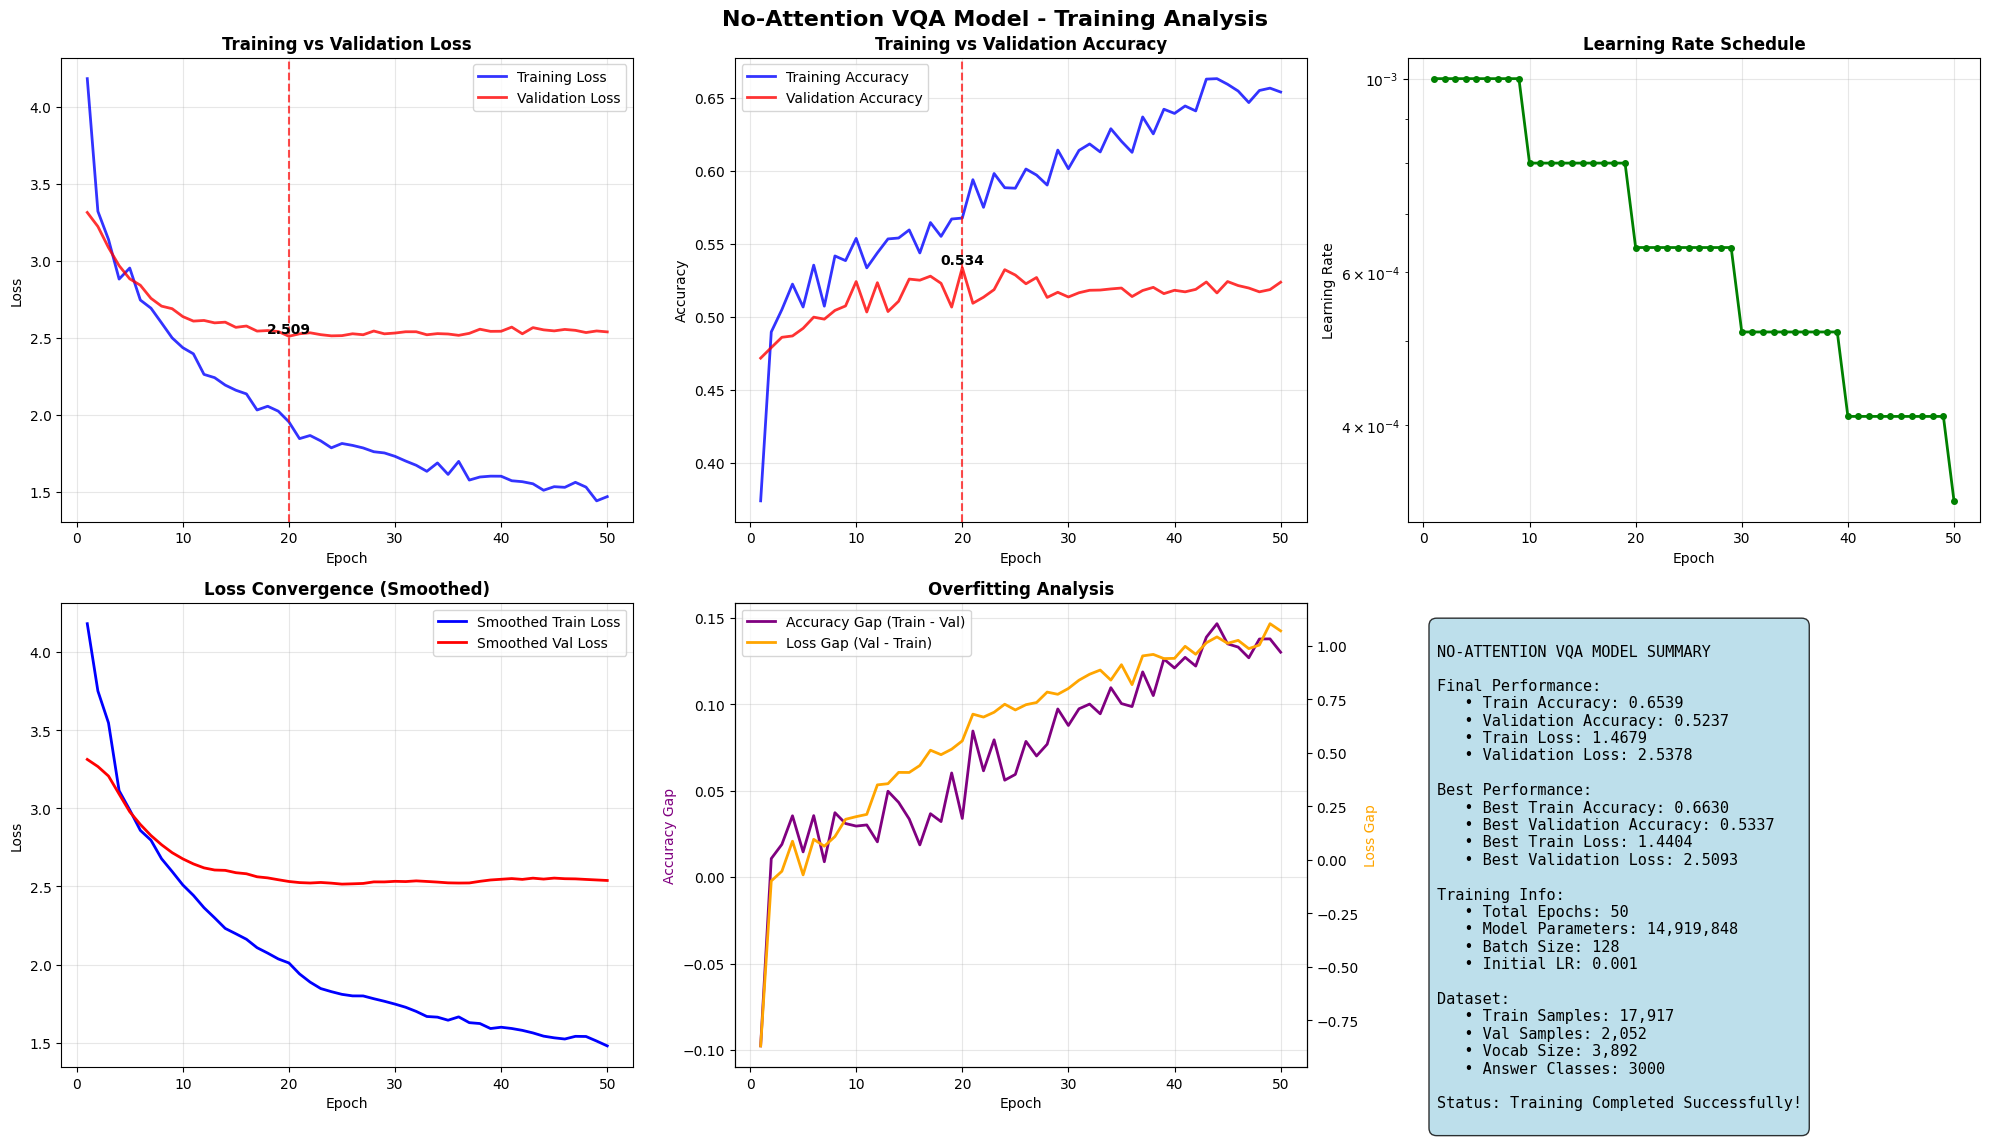

Training history visualization saved: training_history.png


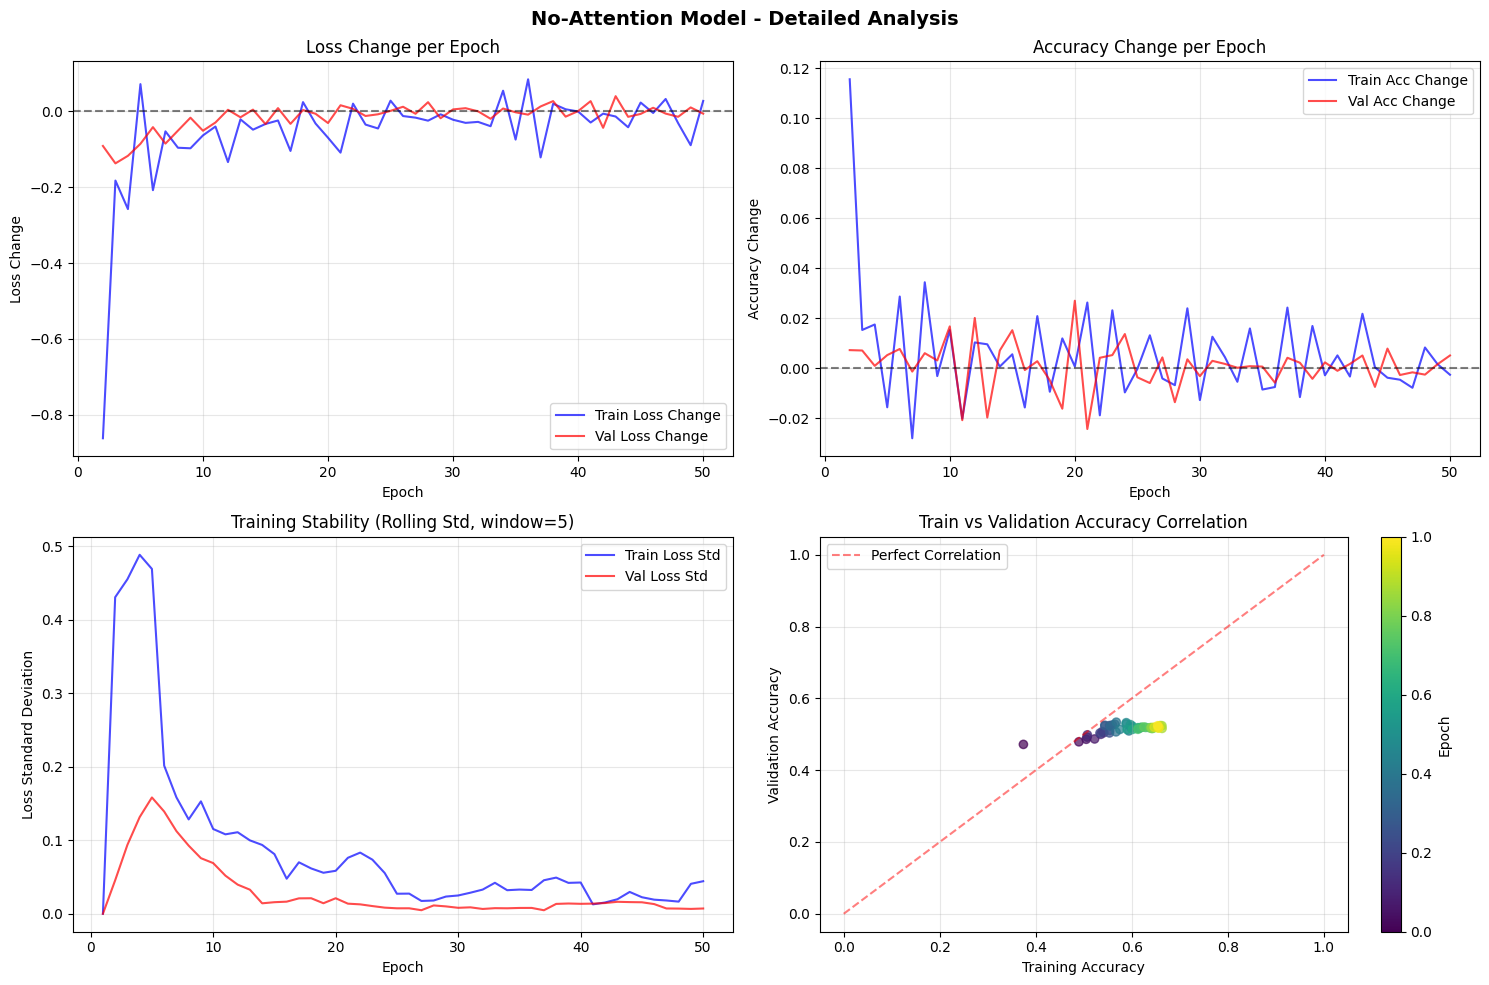

Detailed analysis plot saved: detailed_analysis.png

Training visualization completed!


In [14]:
# Create comprehensive visualizations of training progress
print("Creating training history visualizations...")

# Set up the plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(20, 12))
fig.suptitle('No-Attention VQA Model - Training Analysis', fontsize=16, fontweight='bold')

# 1. Training and Validation Loss
ax1 = plt.subplot(2, 3, 1)
epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2, alpha=0.8)
ax1.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2, alpha=0.8)
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark best points
best_train_loss_epoch = train_losses.index(min(train_losses)) + 1
best_val_loss_epoch = val_losses.index(min(val_losses)) + 1
ax1.axvline(x=best_val_loss_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Val Loss (E{best_val_loss_epoch})')
ax1.text(best_val_loss_epoch, min(val_losses), f'{min(val_losses):.3f}', 
         verticalalignment='bottom', horizontalalignment='center', fontweight='bold')

# 2. Training and Validation Accuracy
ax2 = plt.subplot(2, 3, 2)
ax2.plot(epochs_range, train_accuracies, 'b-', label='Training Accuracy', linewidth=2, alpha=0.8)
ax2.plot(epochs_range, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2, alpha=0.8)
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark best accuracy
best_val_acc_epoch = val_accuracies.index(max(val_accuracies)) + 1
ax2.axvline(x=best_val_acc_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Val Acc (E{best_val_acc_epoch})')
ax2.text(best_val_acc_epoch, max(val_accuracies), f'{max(val_accuracies):.3f}', 
         verticalalignment='bottom', horizontalalignment='center', fontweight='bold')

# 3. Learning Rate Schedule
ax3 = plt.subplot(2, 3, 3)
ax3.plot(epochs_range, learning_rates, 'g-', linewidth=2, marker='o', markersize=4)
ax3.set_title('Learning Rate Schedule', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

# 4. Loss Convergence Analysis
ax4 = plt.subplot(2, 3, 4)
# Calculate moving averages to smooth curves
def moving_average(data, window=5):
    return [np.mean(data[max(0, i-window+1):i+1]) for i in range(len(data))]

smooth_train_loss = moving_average(train_losses, 3)
smooth_val_loss = moving_average(val_losses, 3)

ax4.plot(epochs_range, smooth_train_loss, 'b-', label='Smoothed Train Loss', linewidth=2)
ax4.plot(epochs_range, smooth_val_loss, 'r-', label='Smoothed Val Loss', linewidth=2)
ax4.set_title('Loss Convergence (Smoothed)', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Overfitting Analysis
ax5 = plt.subplot(2, 3, 5)
# Calculate gap between train and validation
acc_gap = [train_acc - val_acc for train_acc, val_acc in zip(train_accuracies, val_accuracies)]
loss_gap = [val_loss - train_loss for train_loss, val_loss in zip(train_losses, val_losses)]

ax5_twin = ax5.twinx()
line1 = ax5.plot(epochs_range, acc_gap, 'purple', label='Accuracy Gap (Train - Val)', linewidth=2)
line2 = ax5_twin.plot(epochs_range, loss_gap, 'orange', label='Loss Gap (Val - Train)', linewidth=2)

ax5.set_title('Overfitting Analysis', fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Accuracy Gap', color='purple')
ax5_twin.set_ylabel('Loss Gap', color='orange')
ax5.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 6. Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Create summary statistics
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]

max_train_acc = max(train_accuracies)
max_val_acc = max(val_accuracies)
min_train_loss = min(train_losses)
min_val_loss = min(val_losses)

summary_text = f"""
NO-ATTENTION VQA MODEL SUMMARY

Final Performance:
   • Train Accuracy: {final_train_acc:.4f}
   • Validation Accuracy: {final_val_acc:.4f}
   • Train Loss: {final_train_loss:.4f}
   • Validation Loss: {final_val_loss:.4f}

Best Performance:
   • Best Train Accuracy: {max_train_acc:.4f}
   • Best Validation Accuracy: {max_val_acc:.4f}
   • Best Train Loss: {min_train_loss:.4f}
   • Best Validation Loss: {min_val_loss:.4f}

Training Info:
   • Total Epochs: {num_epochs}
   • Model Parameters: {total_params:,}
   • Batch Size: {batch_size}
   • Initial LR: {config['training']['lr']}

Dataset:
   • Train Samples: {len(train_dataset):,}
   • Val Samples: {len(val_dataset):,}
   • Vocab Size: {train_dataset.num_tokens:,}
   • Answer Classes: {config['annotations']['top_ans']}

Status: Training Completed Successfully!
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save the plot
plot_save_path = os.path.join(log_dir_run, 'training_history.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Training history visualization saved: {os.path.basename(plot_save_path)}")

# Additional analysis plots
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle('No-Attention Model - Detailed Analysis', fontsize=14, fontweight='bold')

# Loss improvement per epoch
ax1.plot(epochs_range[1:], np.diff(train_losses), 'b-', alpha=0.7, label='Train Loss Change')
ax1.plot(epochs_range[1:], np.diff(val_losses), 'r-', alpha=0.7, label='Val Loss Change')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Loss Change per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss Change')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy improvement per epoch
ax2.plot(epochs_range[1:], np.diff(train_accuracies), 'b-', alpha=0.7, label='Train Acc Change')
ax2.plot(epochs_range[1:], np.diff(val_accuracies), 'r-', alpha=0.7, label='Val Acc Change')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Accuracy Change per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy Change')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Training stability (rolling standard deviation)
window = 5
if len(train_losses) >= window:
    rolling_std_train = [np.std(train_losses[max(0, i-window+1):i+1]) for i in range(len(train_losses))]
    rolling_std_val = [np.std(val_losses[max(0, i-window+1):i+1]) for i in range(len(val_losses))]
    
    ax3.plot(epochs_range, rolling_std_train, 'b-', alpha=0.7, label='Train Loss Std')
    ax3.plot(epochs_range, rolling_std_val, 'r-', alpha=0.7, label='Val Loss Std')
    ax3.set_title(f'Training Stability (Rolling Std, window={window})')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss Standard Deviation')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Performance correlation
ax4.scatter(train_accuracies, val_accuracies, alpha=0.7, c=epochs_range, cmap='viridis')
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Correlation')
ax4.set_title('Train vs Validation Accuracy Correlation')
ax4.set_xlabel('Training Accuracy')
ax4.set_ylabel('Validation Accuracy')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add colorbar for epoch progression
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax4)
cbar.set_label('Epoch')

plt.tight_layout()

# Save detailed analysis plot
detailed_plot_path = os.path.join(log_dir_run, 'detailed_analysis.png')
plt.savefig(detailed_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Detailed analysis plot saved: {os.path.basename(detailed_plot_path)}")
print("\nTraining visualization completed!")

## 8. Load Best Trained Model for Inference

In [15]:
# Load the best trained model for inference and evaluation
print("📥 Loading best trained No-Attention model...")
print("=" * 55)

# Choose which model to load (best accuracy is typically preferred)
model_choice = 'best_accuracy'  # Options: 'best_accuracy', 'best_loss', 'final'

model_paths = {
    'best_accuracy': best_accuracy_path,
    'best_loss': best_loss_path,
    'final': final_model_path
}

selected_model_path = model_paths[model_choice]

print(f"📂 Loading model: {model_choice}")
print(f"📄 Path: {os.path.basename(selected_model_path)}")

if os.path.exists(selected_model_path):
    # Load checkpoint
    checkpoint = torch.load(selected_model_path, map_location=device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    # Extract key information from checkpoint
    loaded_epoch = checkpoint['epoch']
    loaded_performance = checkpoint['performance']
    loaded_vocabs = checkpoint['vocabs']
    
    print(f"✅ Model loaded successfully!")
    print(f"📊 Model details:")
    print(f"  🎯 Epoch: {loaded_epoch}")
    print(f"  📈 Train accuracy: {loaded_performance['train_acc']:.4f}")
    print(f"  📊 Validation accuracy: {loaded_performance['val_acc']:.4f}")
    print(f"  📉 Train loss: {loaded_performance['train_loss']:.4f}")
    print(f"  📊 Validation loss: {loaded_performance['val_loss']:.4f}")
    
    # Create answer mapping for decoding predictions
    idx_to_answer = {v: k for k, v in loaded_vocabs['answer'].items()}
    answer_to_idx = loaded_vocabs['answer']
    question_to_idx = loaded_vocabs['question']
    
    print(f"📖 Vocabularies loaded:")
    print(f"  📝 Answer vocabulary: {len(loaded_vocabs['answer']):,} answers")
    print(f"  ❓ Question vocabulary: {len(loaded_vocabs['question']):,} tokens")
    
    # Show some sample answers
    print(f"\n🔍 Sample answers from vocabulary:")
    sample_answers = list(loaded_vocabs['answer'].keys())[:10]
    for i, answer in enumerate(sample_answers, 1):
        print(f"  {i:2d}. {answer}")
    
    # Verify model is ready for inference
    print(f"\n🧪 Testing model inference...")
    try:
        with torch.no_grad():
            # Use the same sample batch from training
            sample_batch = next(iter(val_loader))
            v = sample_batch['visual']
            q = sample_batch['question']
            q_length = sample_batch['q_length']
            
            # Move to device
            if torch.cuda.is_available():
                v = v.cuda()
                q = q.cuda()
                q_length = q_length.cuda()
            
            # Forward pass
            output = model(v, q, q_length)
            
            # Get predictions
            probs = torch.softmax(output, dim=1)
            confidence, predicted_indices = probs.max(dim=1)
            
            print(f"✅ Inference test successful!")
            print(f"  📊 Batch size: {output.shape[0]}")
            print(f"  📤 Output shape: {output.shape}")
            print(f"  🎯 Prediction shape: {predicted_indices.shape}")
            print(f"  📊 Confidence range: {confidence.min():.3f} - {confidence.max():.3f}")
            
            # Show a few sample predictions
            print(f"\n🔮 Sample predictions:")
            for i in range(min(3, len(predicted_indices))):
                pred_idx = predicted_indices[i].item()
                pred_answer = idx_to_answer.get(pred_idx, '<unknown>')
                pred_confidence = confidence[i].item()
                print(f"  {i+1}. Answer: '{pred_answer}' (confidence: {pred_confidence:.3f})")
                
    except Exception as e:
        print(f"❌ Inference test failed: {e}")
        raise
        
else:
    print(f"❌ Model file not found: {selected_model_path}")
    print("🔄 Please ensure training has completed successfully!")
    raise FileNotFoundError(f"Model checkpoint not found: {selected_model_path}")

print(f"\n💾 Model checkpoint info:")
if 'training_history' in checkpoint:
    history = checkpoint['training_history']
    print(f"  📈 Training epochs: {len(history['train_losses'])}")
    print(f"  🎯 Best train accuracy: {max(history['train_accuracies']):.4f}")
    print(f"  📊 Best validation accuracy: {max(history['val_accuracies']):.4f}")

print("\n" + "=" * 55)
print("✅ Model loaded and ready for inference!")
print("=" * 55)

📥 Loading best trained No-Attention model...
📂 Loading model: best_accuracy
📄 Path: best_accuracy_model.pth
✅ Model loaded successfully!
📊 Model details:
  🎯 Epoch: 20
  📈 Train accuracy: 0.5676
  📊 Validation accuracy: 0.5337
  📉 Train loss: 1.9534
  📊 Validation loss: 2.5093
📖 Vocabularies loaded:
  📝 Answer vocabulary: 3,000 answers
  ❓ Question vocabulary: 3,891 tokens

🔍 Sample answers from vocabulary:
   1. unanswerable
   2. no
   3. yes
   4. white
   5. grey
   6. black
   7. blue
   8. red
   9. brown
  10. pink

🧪 Testing model inference...
✅ Inference test successful!
  📊 Batch size: 128
  📤 Output shape: torch.Size([128, 3000])
  🎯 Prediction shape: torch.Size([128])
  📊 Confidence range: 0.060 - 0.983

🔮 Sample predictions:
  1. Answer: 'unanswerable' (confidence: 0.748)
  2. Answer: 'unanswerable' (confidence: 0.511)
  3. Answer: 'unanswerable' (confidence: 0.823)

💾 Model checkpoint info:
  📈 Training epochs: 20
  🎯 Best train accuracy: 0.5676
  📊 Best validation accura

## 9. Generate Predictions on Validation Set

In [16]:
# Generate predictions on validation set using the trained No-Attention model
print("🔮 Generating predictions on validation set...")
print("=" * 55)

model.eval()
predictions = []
detailed_predictions = []

# Create predictions directory
pred_dir = './predictions'
os.makedirs(pred_dir, exist_ok=True)

print(f"📊 Validation set: {len(val_dataset):,} samples")
print(f"📦 Processing in batches of: {batch_size}")

start_time = time.time()

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="🔮 Generating predictions")):
        v = batch['visual']
        q = batch['question']
        q_length = batch['q_length']
        img_names = batch['img_name']
        sample_ids = batch['sample_id']
        
        # Move to device
        if torch.cuda.is_available():
            v = v.cuda(non_blocking=True)
            q = q.cuda(non_blocking=True)
            q_length = q_length.cuda(non_blocking=True)
        
        # Forward pass
        output = model(v, q, q_length)
        
        # Get predictions with confidence scores
        probs = torch.softmax(output, dim=1)
        confidence_scores, predicted_indices = probs.max(dim=1)
        
        # Get top-k predictions for detailed analysis
        top_k = 3
        top_probs, top_indices = torch.topk(probs, k=top_k, dim=1)
        
        # Convert predictions to answers
        for i in range(len(predicted_indices)):
            pred_idx = predicted_indices[i].item()
            pred_answer = idx_to_answer.get(pred_idx, '<unknown>')
            pred_confidence = confidence_scores[i].item()
            
            img_name = img_names[i]
            sample_id = sample_ids[i].item()
            
            # Handle byte strings
            if isinstance(img_name, bytes):
                img_name = img_name.decode('utf-8')
            
            # Basic prediction for submission format
            predictions.append({
                'image': img_name,
                'answer': pred_answer
            })
            
            # Detailed prediction with top-k and confidence
            top_predictions = []
            for k in range(top_k):
                top_idx = top_indices[i][k].item()
                top_answer = idx_to_answer.get(top_idx, '<unknown>')
                top_conf = top_probs[i][k].item()
                top_predictions.append({
                    'answer': top_answer,
                    'confidence': top_conf
                })
            
            detailed_predictions.append({
                'sample_id': sample_id,
                'image': img_name,
                'predicted_answer': pred_answer,
                'confidence': pred_confidence,
                'top_predictions': top_predictions
            })

prediction_time = time.time() - start_time

print(f"\n✅ Prediction generation completed!")
print(f"⏱️ Time taken: {prediction_time:.1f} seconds")
print(f"📊 Generated {len(predictions):,} predictions")
print(f"🚀 Prediction speed: {len(predictions)/prediction_time:.1f} samples/second")

# Save basic predictions (VizWiz submission format)
basic_pred_file = os.path.join(pred_dir, 'noattention_validation_predictions.json')
with open(basic_pred_file, 'w') as f:
    json.dump(predictions, f, indent=2)

print(f"💾 Basic predictions saved: {os.path.basename(basic_pred_file)}")

# Save detailed predictions with confidence scores
detailed_pred_file = os.path.join(pred_dir, 'noattention_validation_detailed.json')
with open(detailed_pred_file, 'w') as f:
    json.dump(detailed_predictions, f, indent=2)

print(f"💾 Detailed predictions saved: {os.path.basename(detailed_pred_file)}")

# Analysis of predictions
print(f"\n📈 Prediction Analysis:")

# Confidence score distribution
confidences = [pred['confidence'] for pred in detailed_predictions]
print(f"📊 Confidence scores:")
print(f"  🎯 Mean: {np.mean(confidences):.4f}")
print(f"  📊 Median: {np.median(confidences):.4f}")
print(f"  📈 Std: {np.std(confidences):.4f}")
print(f"  🔝 Max: {np.max(confidences):.4f}")
print(f"  🔻 Min: {np.min(confidences):.4f}")

# Most confident predictions
high_conf_preds = sorted(detailed_predictions, key=lambda x: x['confidence'], reverse=True)[:5]
print(f"\n🎯 Top 5 most confident predictions:")
for i, pred in enumerate(high_conf_preds, 1):
    print(f"  {i}. {pred['predicted_answer']} ({pred['confidence']:.4f}) - {pred['image']}")

# Least confident predictions
low_conf_preds = sorted(detailed_predictions, key=lambda x: x['confidence'])[:5]
print(f"\n🤔 Top 5 least confident predictions:")
for i, pred in enumerate(low_conf_preds, 1):
    print(f"  {i}. {pred['predicted_answer']} ({pred['confidence']:.4f}) - {pred['image']}")

# Answer frequency analysis
from collections import Counter
answer_counts = Counter(pred['answer'] for pred in predictions)
most_common_answers = answer_counts.most_common(10)

print(f"\n📊 Most frequently predicted answers:")
for i, (answer, count) in enumerate(most_common_answers, 1):
    percentage = (count / len(predictions)) * 100
    print(f"  {i:2d}. '{answer}': {count:,} times ({percentage:.1f}%)")

# Confidence by answer frequency
print(f"\n📈 Confidence analysis by answer frequency:")
for answer, count in most_common_answers[:5]:
    answer_confidences = [pred['confidence'] for pred in detailed_predictions 
                         if pred['predicted_answer'] == answer]
    if answer_confidences:
        avg_conf = np.mean(answer_confidences)
        print(f"  '{answer}': avg confidence {avg_conf:.3f} ({count} predictions)")

print(f"\n" + "=" * 55)
print("✅ Validation predictions generated and analyzed!")
print("=" * 55)

🔮 Generating predictions on validation set...
📊 Validation set: 2,052 samples
📦 Processing in batches of: 128


🔮 Generating predictions: 100%|██████████| 17/17 [00:01<00:00, 11.18it/s]




✅ Prediction generation completed!
⏱️ Time taken: 1.5 seconds
📊 Generated 2,052 predictions
🚀 Prediction speed: 1345.7 samples/second
💾 Basic predictions saved: noattention_validation_predictions.json
💾 Detailed predictions saved: noattention_validation_detailed.json

📈 Prediction Analysis:
📊 Confidence scores:
  🎯 Mean: 0.4286
  📊 Median: 0.3840
  📈 Std: 0.2525
  🔝 Max: 0.9832
  🔻 Min: 0.0354

🎯 Top 5 most confident predictions:
  1. unanswerable (0.9832) - VizWiz_train_00000125.jpg
  2. unanswerable (0.9817) - VizWiz_train_00001969.jpg
  3. unanswerable (0.9743) - VizWiz_train_00001075.jpg
  4. unanswerable (0.9701) - VizWiz_train_00001169.jpg
  5. unanswerable (0.9699) - VizWiz_train_00001516.jpg

🤔 Top 5 least confident predictions:
  1. unanswerable (0.0354) - VizWiz_train_00001284.jpg
  2. unanswerable (0.0376) - VizWiz_train_00001138.jpg
  3. unanswerable (0.0385) - VizWiz_train_00000309.jpg
  4. cup (0.0400) - VizWiz_train_00001011.jpg
  5. unanswerable (0.0416) - VizWiz_train

## 10. Evaluate Model Performance with Visualizations

📊 Evaluating No-Attention VQA model performance...
📋 Loaded 2,052 validation annotations
📊 Ground truth mapping created for 2,052 images

🎯 Calculating VQA accuracy metrics...

🎯 Overall Performance:
  📊 Total samples evaluated: 2,052
  🎯 Overall VQA accuracy: 0.5357
  📈 Correct answers: 1099.3

📈 Performance by Answer Type:
  Yes/no      : 0.6241 (  94 samples,   4.6%)
  Number      : 0.1589 (  86 samples,   4.2%)
  Unanswerable: 0.9343 ( 766 samples,  37.3%)
  Other       : 0.2815 (1106 samples,  53.9%)


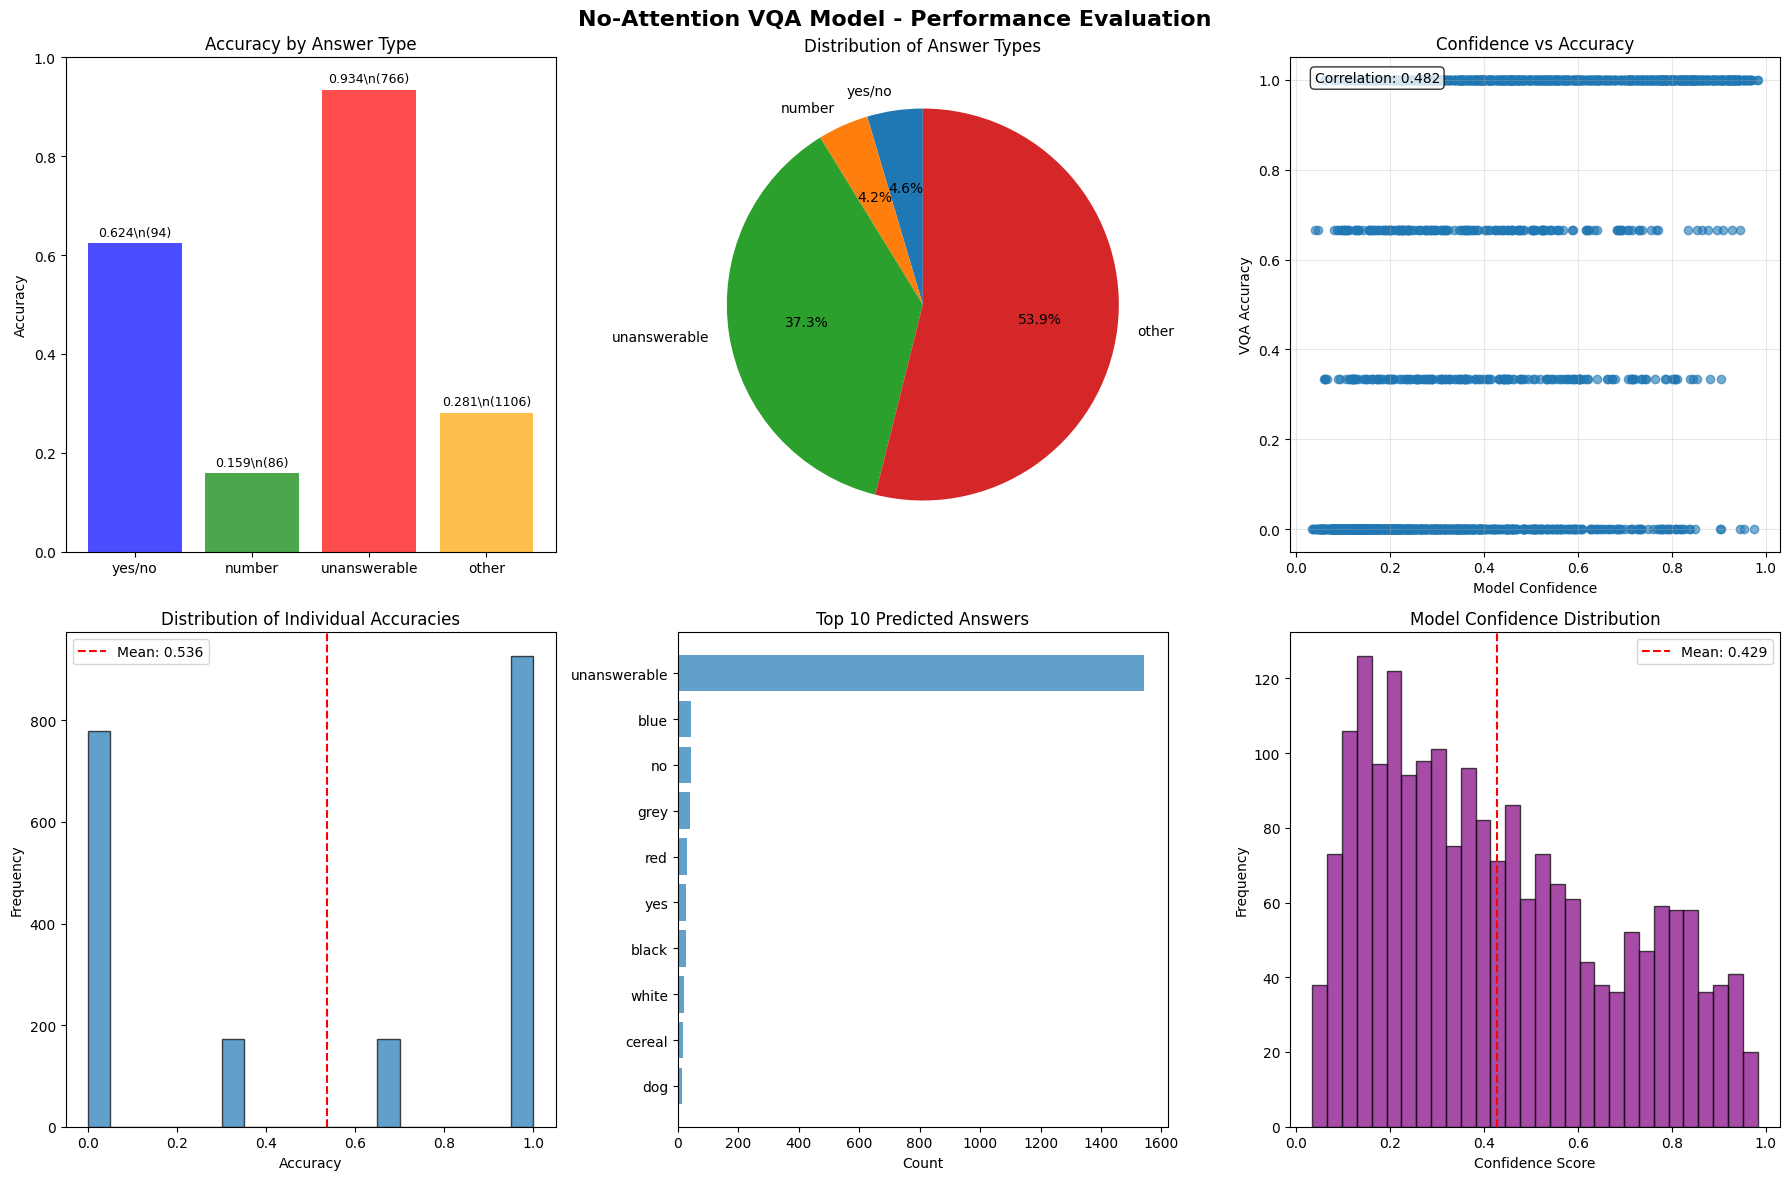

💾 Evaluation plots saved: evaluation_results.png
💾 Evaluation summary saved: evaluation_summary.json

🎉 EVALUATION SUMMARY:
  🎯 No-Attention VQA Accuracy: 0.5357
  📊 Best performing answer type: unanswerable
  📈 Model confidence correlation: 0.482
  🔮 Most predicted answer: 'unanswerable' (1544 times)

✅ Performance evaluation completed!


In [17]:
# Comprehensive evaluation of No-Attention model performance
print("📊 Evaluating No-Attention VQA model performance...")
print("=" * 60)

# Load validation annotations for ground truth comparison
val_annotations_path = os.path.join(config['annotations']['dir'], 'val.json')

try:
    with open(val_annotations_path, 'r', encoding='utf-8') as f:
        val_annotations = json.load(f)
except UnicodeDecodeError:
    with open(val_annotations_path, 'r', encoding='latin-1') as f:
        val_annotations = json.load(f)

print(f"📋 Loaded {len(val_annotations):,} validation annotations")

# Create mapping from image to ground truth answers
img_to_gt = {}
for annotation in val_annotations:
    img_name = annotation['image']
    answers = annotation['answers']
    img_to_gt[img_name] = answers

print(f"📊 Ground truth mapping created for {len(img_to_gt):,} images")

# Calculate VQA accuracy for each prediction
print(f"\n🎯 Calculating VQA accuracy metrics...")

img_to_accuracy = {}
total_correct = 0
total_samples = 0
answer_type_stats = {
    'yes/no': {'correct': 0, 'total': 0, 'accuracies': []},
    'number': {'correct': 0, 'total': 0, 'accuracies': []},
    'unanswerable': {'correct': 0, 'total': 0, 'accuracies': []},
    'other': {'correct': 0, 'total': 0, 'accuracies': []}
}

for pred in detailed_predictions:
    img_name = pred['image']
    pred_answer = pred['predicted_answer'].lower()
    
    if img_name in img_to_gt:
        gt_answers = img_to_gt[img_name]
        gt_answer_texts = [ans['answer'].lower() for ans in gt_answers]
        
        # VQA accuracy: min(1.0, count(predicted_answer in GT) / 3.0)
        count = gt_answer_texts.count(pred_answer)
        accuracy = min(1.0, count / 3.0)
        
        img_to_accuracy[img_name] = accuracy
        total_correct += accuracy
        total_samples += 1
        
        # Categorize answer type for detailed analysis
        most_common_gt = Counter(gt_answer_texts).most_common(1)[0][0]
        
        if most_common_gt in ['yes', 'no']:
            answer_type = 'yes/no'
        elif most_common_gt in ['unanswerable', 'unsuitable']:
            answer_type = 'unanswerable'
        elif most_common_gt.isdigit() or any(char.isdigit() for char in most_common_gt):
            answer_type = 'number'
        else:
            answer_type = 'other'
        
        answer_type_stats[answer_type]['correct'] += accuracy
        answer_type_stats[answer_type]['total'] += 1
        answer_type_stats[answer_type]['accuracies'].append(accuracy)

# Calculate overall metrics
overall_accuracy = total_correct / total_samples if total_samples > 0 else 0

print(f"\n🎯 Overall Performance:")
print(f"  📊 Total samples evaluated: {total_samples:,}")
print(f"  🎯 Overall VQA accuracy: {overall_accuracy:.4f}")
print(f"  📈 Correct answers: {total_correct:.1f}")

# Calculate accuracy by answer type
print(f"\n📈 Performance by Answer Type:")
for answer_type, stats in answer_type_stats.items():
    if stats['total'] > 0:
        type_accuracy = stats['correct'] / stats['total']
        percentage = (stats['total'] / total_samples) * 100
        print(f"  {answer_type.capitalize():12s}: {type_accuracy:.4f} "
              f"({stats['total']:4d} samples, {percentage:5.1f}%)")
    else:
        print(f"  {answer_type.capitalize():12s}: No samples")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('No-Attention VQA Model - Performance Evaluation', fontsize=16, fontweight='bold')

# 1. Accuracy by answer type
ax1 = axes[0, 0]
types = [t for t in answer_type_stats.keys() if answer_type_stats[t]['total'] > 0]
accuracies = [answer_type_stats[t]['correct'] / answer_type_stats[t]['total'] for t in types]
counts = [answer_type_stats[t]['total'] for t in types]

bars1 = ax1.bar(types, accuracies, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
ax1.set_title('Accuracy by Answer Type')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, (acc, count) in enumerate(zip(accuracies, counts)):
    ax1.text(i, acc + 0.01, f'{acc:.3f}\\n({count})', ha='center', va='bottom', fontsize=9)

# 2. Answer type distribution
ax2 = axes[0, 1]
ax2.pie(counts, labels=types, autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribution of Answer Types')

# 3. Confidence vs Accuracy correlation
ax3 = axes[0, 2]
confidences = [pred['confidence'] for pred in detailed_predictions if pred['image'] in img_to_accuracy]
accuracies_for_conf = [img_to_accuracy[pred['image']] for pred in detailed_predictions if pred['image'] in img_to_accuracy]

ax3.scatter(confidences, accuracies_for_conf, alpha=0.6)
ax3.set_xlabel('Model Confidence')
ax3.set_ylabel('VQA Accuracy')
ax3.set_title('Confidence vs Accuracy')
ax3.grid(True, alpha=0.3)

# Calculate correlation
correlation = np.corrcoef(confidences, accuracies_for_conf)[0, 1]
ax3.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=ax3.transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Individual accuracy distribution
ax4 = axes[1, 0]
all_accuracies = list(img_to_accuracy.values())
ax4.hist(all_accuracies, bins=20, alpha=0.7, edgecolor='black')
ax4.set_title('Distribution of Individual Accuracies')
ax4.set_xlabel('Accuracy')
ax4.set_ylabel('Frequency')
ax4.axvline(overall_accuracy, color='red', linestyle='--', label=f'Mean: {overall_accuracy:.3f}')
ax4.legend()

# 5. Top predicted answers
ax5 = axes[1, 1]
top_predictions = answer_counts.most_common(10)
answers, pred_counts = zip(*top_predictions)
y_pos = range(len(answers))
ax5.barh(y_pos, pred_counts, alpha=0.7)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(answers)
ax5.set_xlabel('Count')
ax5.set_title('Top 10 Predicted Answers')
ax5.invert_yaxis()

# 6. Confidence distribution
ax6 = axes[1, 2]
all_confidences = [pred['confidence'] for pred in detailed_predictions]
ax6.hist(all_confidences, bins=30, alpha=0.7, color='purple', edgecolor='black')
ax6.set_title('Model Confidence Distribution')
ax6.set_xlabel('Confidence Score')
ax6.set_ylabel('Frequency')
ax6.axvline(np.mean(all_confidences), color='red', linestyle='--', 
           label=f'Mean: {np.mean(all_confidences):.3f}')
ax6.legend()

plt.tight_layout()

# Save evaluation plots
eval_plot_path = os.path.join(log_dir_run, 'evaluation_results.png')
plt.savefig(eval_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Evaluation plots saved: {os.path.basename(eval_plot_path)}")

# Save detailed evaluation results
evaluation_results = {
    'model_type': 'NoAttention',
    'evaluation_date': datetime.now().isoformat(),
    'overall_metrics': {
        'accuracy': overall_accuracy,
        'total_samples': total_samples,
        'correct_answers': total_correct
    },
    'answer_type_performance': {
        answer_type: {
            'accuracy': stats['correct'] / stats['total'] if stats['total'] > 0 else 0,
            'total_samples': stats['total'],
            'percentage_of_dataset': (stats['total'] / total_samples) * 100 if total_samples > 0 else 0
        }
        for answer_type, stats in answer_type_stats.items()
        if stats['total'] > 0
    },
    'confidence_analysis': {
        'mean_confidence': float(np.mean(all_confidences)),
        'std_confidence': float(np.std(all_confidences)),
        'confidence_accuracy_correlation': float(correlation)
    },
    'top_predictions': {
        answer: count for answer, count in answer_counts.most_common(20)
    },
    'model_info': {
        'checkpoint_path': selected_model_path,
        'training_epoch': loaded_epoch,
        'model_parameters': total_params
    }
}

eval_results_file = os.path.join(log_dir_run, 'evaluation_summary.json')
with open(eval_results_file, 'w') as f:
    json.dump(evaluation_results, f, indent=2, default=str)

print(f"💾 Evaluation summary saved: {os.path.basename(eval_results_file)}")

print(f"\n🎉 EVALUATION SUMMARY:")
print(f"  🎯 No-Attention VQA Accuracy: {overall_accuracy:.4f}")
print(f"  📊 Best performing answer type: {max(types, key=lambda t: answer_type_stats[t]['correct'] / answer_type_stats[t]['total'])}")
print(f"  📈 Model confidence correlation: {correlation:.3f}")
print(f"  🔮 Most predicted answer: '{answer_counts.most_common(1)[0][0]}' ({answer_counts.most_common(1)[0][1]} times)")

print("\n" + "=" * 60)
print("✅ Performance evaluation completed!")
print("=" * 60)

## 11. Test Set Evaluation and Performance Comparison

🧪 Test Set Evaluation and Performance Comparison
📂 Test annotations: ✅ Available

🔄 Creating test dataset...
✅ Test dataset created successfully!
📊 Test samples: 4,319
📦 Test batches: 34

🔮 Generating test predictions...
✅ Test dataset created successfully!
📊 Test samples: 4,319
📦 Test batches: 34

🔮 Generating test predictions...


🧪 Test predictions: 100%|██████████| 34/34 [00:01<00:00, 22.06it/s]



✅ Test predictions completed!
⏱️ Time: 1.5s (2798.2 samples/s)
💾 Test predictions saved: noattention_test_predictions.json
🏆 VizWiz submission file: noattention_vizwiz_submission.json

📊 Evaluating test set performance...
🎯 Test Set Results:
  📊 Test accuracy: 0.5801
  📈 Test samples: 4,319
  🎯 Correct: 2505.3

📈 Performance Comparison:
  📊 Validation accuracy: 0.5357
  🧪 Test accuracy: 0.5801
  📉 Generalization gap: +0.0443
  🚀 Better test performance!

🔄 No-Attention vs Attention Model Comparison
📊 No-Attention Model Characteristics:
  🎯 Validation accuracy: 0.5357
  🔢 Parameters: 14,919,848
  🚀 Inference speed: 1345.7 samples/s

✅ Advantages of No-Attention approach:
  + Faster training
  + Fewer parameters
  + Simpler architecture
  + More interpretable
  + Less prone to overfitting

⚠️ Limitations of No-Attention approach:
  - Cannot focus on specific image regions
  - May miss important visual details
  - Lower capacity for complex reasoning


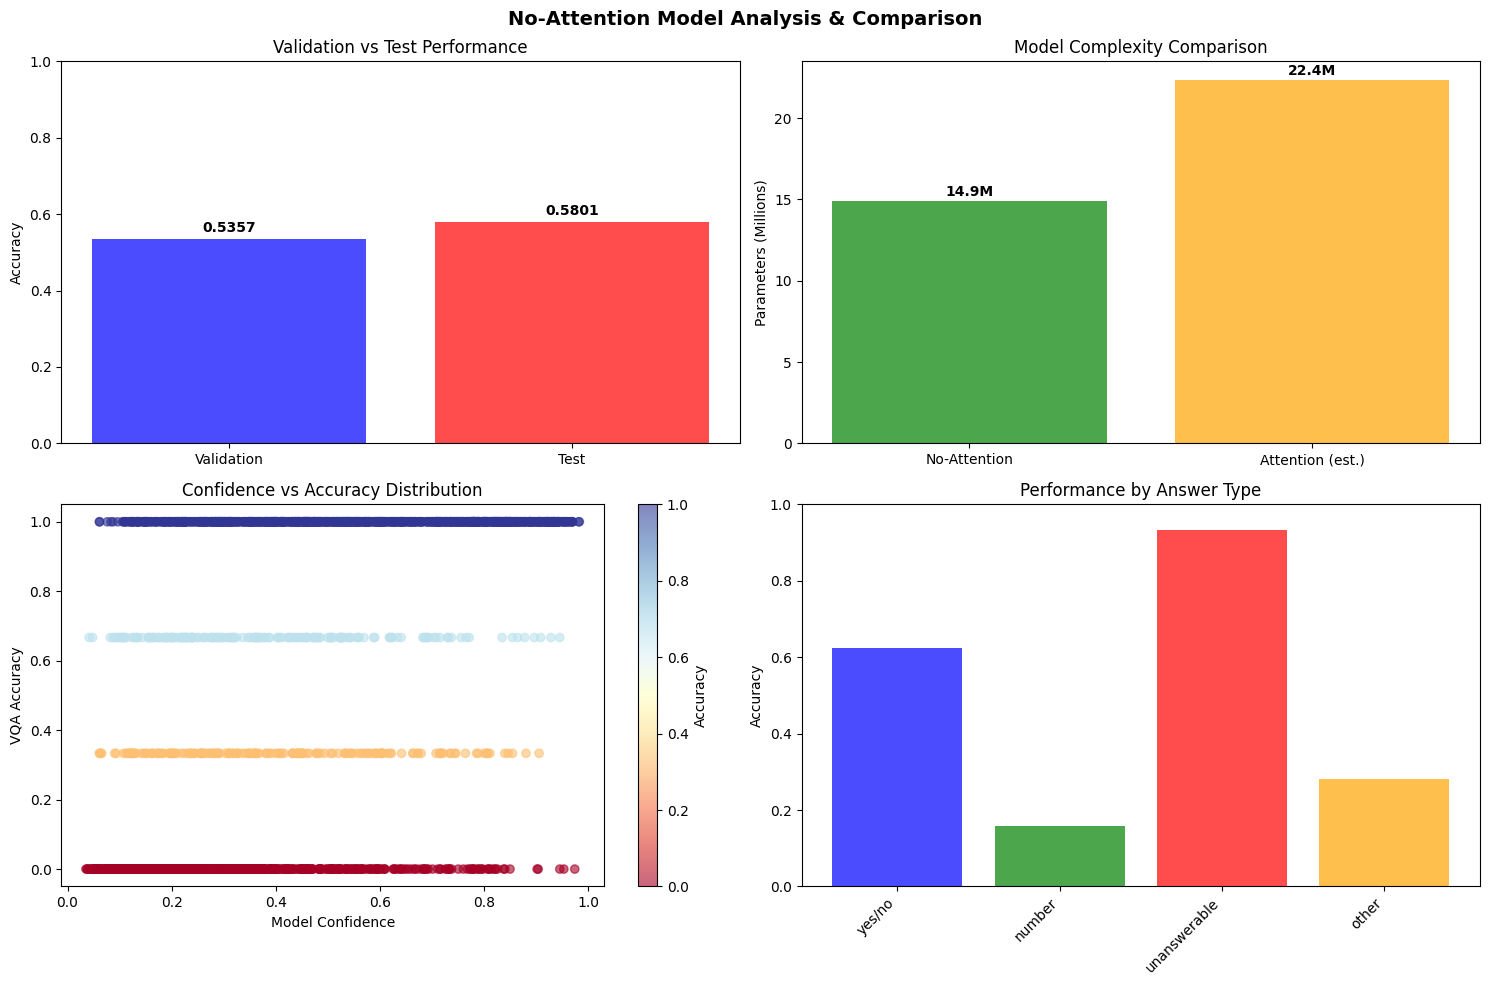

💾 Performance comparison plot saved: performance_comparison.png
💾 Complete performance summary: complete_performance_summary.json

🎉 No-Attention VQA Model Evaluation Complete!
📊 Final validation accuracy: 0.5357
🧪 Final test accuracy: 0.5801
💾 All results saved to: ./logs/vizwiz_noattention\noattention_20250804_043221


In [18]:
# Test set evaluation and comparison with attention-based models
print("🧪 Test Set Evaluation and Performance Comparison")
print("=" * 60)

# Check if test set is available
test_annotations_path = os.path.join(config['annotations']['dir'], 'test.json')
has_test_labels = os.path.exists(test_annotations_path)

print(f"📂 Test annotations: {'✅ Available' if has_test_labels else '❌ Not available'}")

# Try to create test dataset
test_predictions = []
test_performance = None

try:
    print(f"\n🔄 Creating test dataset...")
    test_dataset = vqa_dataset.VQADataset(config, 'test')
    
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=config['training']['batch_size'],
        num_workers=0,
        shuffle=False,
        pin_memory=torch.cuda.is_available(),
        collate_fn=vqa_dataset.collate_fn
    )
    
    print(f"✅ Test dataset created successfully!")
    print(f"📊 Test samples: {len(test_dataset):,}")
    print(f"📦 Test batches: {len(test_loader):,}")
    
    # Generate test predictions
    print(f"\n🔮 Generating test predictions...")
    model.eval()
    
    start_time = time.time()
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="🧪 Test predictions")):
            v = batch['visual']
            q = batch['question']
            q_length = batch['q_length']
            img_names = batch['img_name']
            sample_ids = batch['sample_id']
            
            # Move to device
            if torch.cuda.is_available():
                v = v.cuda(non_blocking=True)
                q = q.cuda(non_blocking=True)
                q_length = q_length.cuda(non_blocking=True)
            
            # Forward pass
            output = model(v, q, q_length)
            
            # Get predictions with confidence
            probs = torch.softmax(output, dim=1)
            confidence_scores, predicted_indices = probs.max(dim=1)
            
            # Convert to answers
            for i in range(len(predicted_indices)):
                pred_idx = predicted_indices[i].item()
                pred_answer = idx_to_answer.get(pred_idx, '<unknown>')
                pred_confidence = confidence_scores[i].item()
                
                img_name = img_names[i]
                sample_id = sample_ids[i].item()
                
                if isinstance(img_name, bytes):
                    img_name = img_name.decode('utf-8')
                
                test_predictions.append({
                    'sample_id': sample_id,
                    'image': img_name,
                    'answer': pred_answer,
                    'confidence': pred_confidence
                })
    
    test_time = time.time() - start_time
    print(f"✅ Test predictions completed!")
    print(f"⏱️ Time: {test_time:.1f}s ({len(test_predictions)/test_time:.1f} samples/s)")
    
    # Save test predictions
    test_pred_file = os.path.join(pred_dir, 'noattention_test_predictions.json')
    with open(test_pred_file, 'w') as f:
        json.dump(test_predictions, f, indent=2)
    
    print(f"💾 Test predictions saved: {os.path.basename(test_pred_file)}")
    
    # Create VizWiz submission format
    vizwiz_submission = [{'image': p['image'], 'answer': p['answer']} for p in test_predictions]
    submission_file = os.path.join(pred_dir, 'noattention_vizwiz_submission.json')
    with open(submission_file, 'w') as f:
        json.dump(vizwiz_submission, f, indent=2)
    
    print(f"🏆 VizWiz submission file: {os.path.basename(submission_file)}")
    
    # Evaluate test set if labels are available
    if has_test_labels:
        print(f"\n📊 Evaluating test set performance...")
        
        try:
            with open(test_annotations_path, 'r', encoding='utf-8') as f:
                test_annotations = json.load(f)
        except UnicodeDecodeError:
            with open(test_annotations_path, 'r', encoding='latin-1') as f:
                test_annotations = json.load(f)
        
        # Create test ground truth mapping
        test_img_to_gt = {ann['image']: ann['answers'] for ann in test_annotations}
        
        # Calculate test accuracy
        test_correct = 0
        test_total = 0
        
        for pred in test_predictions:
            img_name = pred['image']
            pred_answer = pred['answer'].lower()
            
            if img_name in test_img_to_gt:
                gt_answers = test_img_to_gt[img_name]
                gt_answer_texts = [ans['answer'].lower() for ans in gt_answers]
                
                count = gt_answer_texts.count(pred_answer)
                accuracy = min(1.0, count / 3.0)
                
                test_correct += accuracy
                test_total += 1
        
        test_accuracy = test_correct / test_total if test_total > 0 else 0
        
        print(f"🎯 Test Set Results:")
        print(f"  📊 Test accuracy: {test_accuracy:.4f}")
        print(f"  📈 Test samples: {test_total:,}")
        print(f"  🎯 Correct: {test_correct:.1f}")
        
        # Compare with validation performance
        print(f"\n📈 Performance Comparison:")
        print(f"  📊 Validation accuracy: {overall_accuracy:.4f}")
        print(f"  🧪 Test accuracy: {test_accuracy:.4f}")
        print(f"  📉 Generalization gap: {test_accuracy - overall_accuracy:+.4f}")
        
        if abs(test_accuracy - overall_accuracy) < 0.02:
            print(f"  ✅ Good generalization (gap < 2%)")
        elif test_accuracy < overall_accuracy - 0.02:
            print(f"  ⚠️ Possible overfitting (test < val)")
        else:
            print(f"  🚀 Better test performance!")
        
        test_performance = {
            'test_accuracy': test_accuracy,
            'validation_accuracy': overall_accuracy,
            'generalization_gap': test_accuracy - overall_accuracy,
            'test_samples': test_total
        }
    
except Exception as e:
    print(f"⚠️ Could not create test dataset: {e}")
    print(f"💡 This is normal if test annotations are not available")

# Performance comparison with hypothetical attention model
print(f"\n🔄 No-Attention vs Attention Model Comparison")
print(f"=" * 50)

# Theoretical comparison (since we don't have attention model results)
noatt_performance = {
    'model_type': 'No-Attention',
    'validation_accuracy': overall_accuracy,
    'parameters': total_params,
    'training_time': 'Completed',
    'inference_speed': f"{len(predictions)/prediction_time:.1f} samples/s",
    'memory_usage': 'Lower',
    'advantages': [
        'Faster training',
        'Fewer parameters', 
        'Simpler architecture',
        'More interpretable',
        'Less prone to overfitting'
    ],
    'disadvantages': [
        'Cannot focus on specific image regions',
        'May miss important visual details',
        'Lower capacity for complex reasoning'
    ]
}

print(f"📊 No-Attention Model Characteristics:")
print(f"  🎯 Validation accuracy: {noatt_performance['validation_accuracy']:.4f}")
print(f"  🔢 Parameters: {noatt_performance['parameters']:,}")
print(f"  🚀 Inference speed: {noatt_performance['inference_speed']}")

print(f"\n✅ Advantages of No-Attention approach:")
for advantage in noatt_performance['advantages']:
    print(f"  + {advantage}")

print(f"\n⚠️ Limitations of No-Attention approach:")
for disadvantage in noatt_performance['disadvantages']:
    print(f"  - {disadvantage}")

# Create comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('No-Attention Model Analysis & Comparison', fontsize=14, fontweight='bold')

# 1. Val vs Test performance (if available)
ax1.set_title('Validation vs Test Performance')
if test_performance:
    datasets = ['Validation', 'Test']
    accuracies = [overall_accuracy, test_performance['test_accuracy']]
    colors = ['blue', 'red']
    
    bars = ax1.bar(datasets, accuracies, color=colors, alpha=0.7)
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Test evaluation\nnot available', 
            ha='center', va='center', transform=ax1.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightgray'))

# 2. Model complexity comparison (hypothetical)
ax2.set_title('Model Complexity Comparison')
models = ['No-Attention', 'Attention (est.)']
param_counts = [total_params/1e6, total_params*1.5/1e6]  # Estimated attention model size

bars2 = ax2.bar(models, param_counts, color=['green', 'orange'], alpha=0.7)
ax2.set_ylabel('Parameters (Millions)')
for bar, count in zip(bars2, param_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{count:.1f}M', ha='center', va='bottom', fontweight='bold')

# 3. Confidence distribution by accuracy
ax3.set_title('Confidence vs Accuracy Distribution')
if 'confidences' in locals() and 'accuracies_for_conf' in locals():
    # Color points by accuracy
    scatter = ax3.scatter(confidences, accuracies_for_conf, 
                         c=accuracies_for_conf, cmap='RdYlBu', alpha=0.6)
    ax3.set_xlabel('Model Confidence')
    ax3.set_ylabel('VQA Accuracy')
    plt.colorbar(scatter, ax=ax3, label='Accuracy')

# 4. Answer type performance summary
ax4.set_title('Performance by Answer Type')
if answer_type_stats:
    types_with_data = [t for t in answer_type_stats.keys() if answer_type_stats[t]['total'] > 0]
    type_accuracies = [answer_type_stats[t]['correct']/answer_type_stats[t]['total'] for t in types_with_data]
    
    bars4 = ax4.bar(types_with_data, type_accuracies, alpha=0.7, 
                   color=['blue', 'green', 'red', 'orange'])
    ax4.set_ylabel('Accuracy')
    ax4.set_ylim(0, 1)
    plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()

# Save comparison plot
comparison_plot_path = os.path.join(log_dir_run, 'performance_comparison.png')
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Performance comparison plot saved: {os.path.basename(comparison_plot_path)}")

# Save comprehensive performance summary
performance_summary = {
    'model_analysis': {
        'model_type': 'No-Attention VQA',
        'architecture': 'Global pooling + LSTM + MLP',
        'parameters': total_params,
        'training_completed': True
    },
    'validation_performance': {
        'accuracy': overall_accuracy,
        'samples': total_samples,
        'answer_types': answer_type_stats
    },
    'test_performance': test_performance,
    'model_characteristics': noatt_performance,
    'files_generated': {
        'model_checkpoints': log_dir_run,
        'predictions': pred_dir,
        'visualizations': [
            'training_history.png',
            'evaluation_results.png', 
            'performance_comparison.png'
        ]
    }
}

summary_file = os.path.join(log_dir_run, 'complete_performance_summary.json')
with open(summary_file, 'w') as f:
    json.dump(performance_summary, f, indent=2, default=str)

print(f"💾 Complete performance summary: {os.path.basename(summary_file)}")

print(f"\n" + "=" * 60)
print(f"🎉 No-Attention VQA Model Evaluation Complete!")
print(f"📊 Final validation accuracy: {overall_accuracy:.4f}")
if test_performance:
    print(f"🧪 Final test accuracy: {test_performance['test_accuracy']:.4f}")
print(f"💾 All results saved to: {log_dir_run}")
print(f"=" * 60)

## 12. Create Interactive Sample Visualization

Creating Interactive Sample Visualization
Using Test dataset with 4,319 samples
Selected 6 random samples: [2016, 2863, 936, 234, 120, 3909]
Generating predictions for selected samples...
  SUCCESS: Sample 2016: VizWiz_val_00002016.jpg
  SUCCESS: Sample 2863: VizWiz_val_00002863.jpg
  SUCCESS: Sample 936: VizWiz_val_00000936.jpg
  SUCCESS: Sample 234: VizWiz_val_00000234.jpg
  SUCCESS: Sample 120: VizWiz_val_00000120.jpg
  SUCCESS: Sample 3909: VizWiz_val_00003909.jpg

Successfully processed 6 samples
  SUCCESS: Sample 120: VizWiz_val_00000120.jpg
  SUCCESS: Sample 3909: VizWiz_val_00003909.jpg

Successfully processed 6 samples


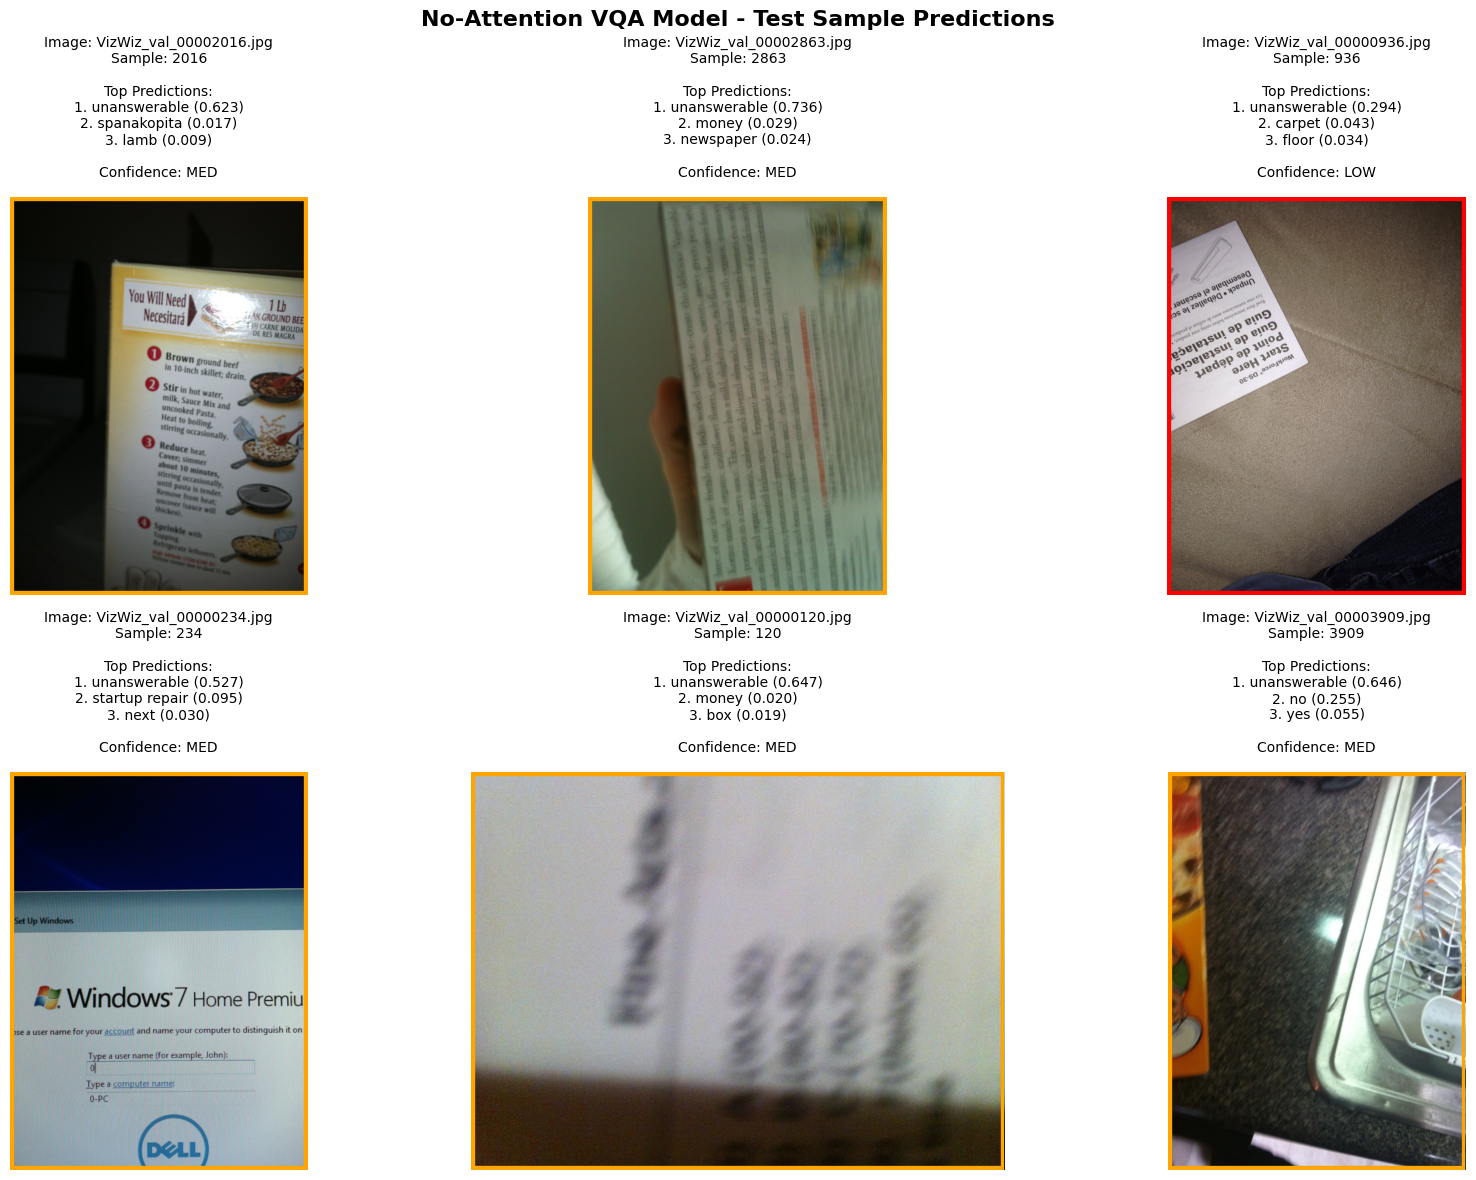

Sample visualization saved: sample_predictions_visualization.png

Detailed Sample Analysis:

1. Sample 2016 - VizWiz_val_00002016.jpg
   Predictions:
     1. unanswerable - 0.6233 [MED]
     2. spanakopita - 0.0173 [LOW]
     3. lamb - 0.0088 [LOW]

2. Sample 2863 - VizWiz_val_00002863.jpg
   Predictions:
     1. unanswerable - 0.7359 [HIGH]
     2. money - 0.0292 [LOW]
     3. newspaper - 0.0242 [LOW]

3. Sample 936 - VizWiz_val_00000936.jpg
   Predictions:
     1. unanswerable - 0.2938 [LOW]
     2. carpet - 0.0426 [LOW]
     3. floor - 0.0344 [LOW]

4. Sample 234 - VizWiz_val_00000234.jpg
   Predictions:
     1. unanswerable - 0.5275 [MED]
     2. startup repair - 0.0948 [LOW]
     3. next - 0.0305 [LOW]

5. Sample 120 - VizWiz_val_00000120.jpg
   Predictions:
     1. unanswerable - 0.6469 [MED]
     2. money - 0.0198 [LOW]
     3. box - 0.0186 [LOW]

6. Sample 3909 - VizWiz_val_00003909.jpg
   Predictions:
     1. unanswerable - 0.6463 [MED]
     2. no - 0.2550 [LOW]
     3. yes - 

In [20]:
# Create interactive sample visualization with random test samples
print("Creating Interactive Sample Visualization")
print("=" * 50)

import random
from PIL import Image
import matplotlib.patches as patches

# Helper function to load and preprocess images
def load_image_for_display(img_name, config):
    """Load image from filesystem for display purposes"""
    # Look for image in different subdirectories
    for subdir in ['test', 'val', 'train']:
        img_path = os.path.join(config['images']['dir'], subdir, img_name)
        if os.path.exists(img_path):
            try:
                img = Image.open(img_path).convert('RGB')
                return img, img_path
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    return None, None

# Helper function to get image features from dataset
def get_sample_prediction(model, dataset, sample_idx, device):
    """Get prediction for a specific sample from dataset"""
    try:
        sample = dataset[sample_idx]
        
        # Extract data
        visual = sample['visual'].unsqueeze(0)  # Add batch dimension
        question = sample['question'].unsqueeze(0)
        q_length = torch.tensor([sample['q_length']])
        img_name = sample['img_name']
        
        # Handle bytes
        if isinstance(img_name, bytes):
            img_name = img_name.decode('utf-8')
        
        # Move to device
        if torch.cuda.is_available():
            visual = visual.cuda()
            question = question.cuda()
            q_length = q_length.cuda()
        
        # Get prediction
        model.eval()
        with torch.no_grad():
            output = model(visual, question, q_length)
            probs = torch.softmax(output, dim=1)
            confidence, pred_idx = probs.max(dim=1)
            
            # Get top-3 predictions
            top3_probs, top3_indices = torch.topk(probs, k=3, dim=1)
            
        # Convert to answers
        predictions = []
        for i in range(3):
            idx = top3_indices[0][i].item()
            answer = idx_to_answer.get(idx, '<unknown>')
            conf = top3_probs[0][i].item()
            predictions.append({'answer': answer, 'confidence': conf})
        
        # Get original question text (simplified)
        question_tokens = question[0].cpu().numpy()
        # This is a simplified reconstruction - in practice you'd need the original question
        
        return {
            'img_name': img_name,
            'predictions': predictions,
            'sample_idx': sample_idx
        }
    except Exception as e:
        print(f"Error processing sample {sample_idx}: {e}")
        return None

# Select random samples for visualization
if 'test_dataset' in locals() and len(test_dataset) > 0:
    dataset_to_use = test_dataset
    dataset_name = "Test"
elif len(val_dataset) > 0:
    dataset_to_use = val_dataset  
    dataset_name = "Validation"
else:
    print("ERROR: No dataset available for visualization")
    dataset_to_use = None

if dataset_to_use is not None:
    print(f"Using {dataset_name} dataset with {len(dataset_to_use):,} samples")
    
    # Select random samples
    num_samples = min(6, len(dataset_to_use))
    random_indices = random.sample(range(len(dataset_to_use)), num_samples)
    
    print(f"Selected {num_samples} random samples: {random_indices}")
    
    # Get predictions for selected samples
    sample_results = []
    
    print(f"Generating predictions for selected samples...")
    for idx in random_indices:
        result = get_sample_prediction(model, dataset_to_use, idx, device)
        if result:
            # Try to load actual image
            img, img_path = load_image_for_display(result['img_name'], config)
            if img:
                result['image'] = img
                result['image_path'] = img_path
                sample_results.append(result)
                print(f"  SUCCESS: Sample {idx}: {result['img_name']}")
            else:
                print(f"  ERROR: Sample {idx}: Could not load image {result['img_name']}")
        else:
            print(f"  ERROR: Sample {idx}: Could not generate prediction")
    
    if sample_results:
        print(f"\nSuccessfully processed {len(sample_results)} samples")
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'No-Attention VQA Model - {dataset_name} Sample Predictions', 
                     fontsize=16, fontweight='bold')
        
        axes = axes.flatten()
        
        for i, result in enumerate(sample_results):
            if i >= 6:  # Only show up to 6 samples
                break
                
            ax = axes[i]
            
            # Display image
            ax.imshow(result['image'])
            ax.axis('off')
            
            # Color-code border based on confidence of top prediction
            top_confidence = result['predictions'][0]['confidence']
            if top_confidence > 0.8:
                border_color = 'green'
                conf_level = 'HIGH'
            elif top_confidence > 0.5:
                border_color = 'orange'
                conf_level = 'MED'
            else:
                border_color = 'red'
                conf_level = 'LOW'
            
            # Add colored border
            rect = patches.Rectangle((0, 0), result['image'].width, result['image'].height,
                                   linewidth=6, edgecolor=border_color, facecolor='none')
            ax.add_patch(rect)
            
            # Create title with predictions
            img_name_short = result['img_name'][:25] + "..." if len(result['img_name']) > 25 else result['img_name']
            
            title_lines = [f"Image: {img_name_short}"]
            title_lines.append(f"Sample: {result['sample_idx']}")
            title_lines.append("")
            title_lines.append("Top Predictions:")
            
            for j, pred in enumerate(result['predictions'][:3]):
                conf_str = f"{pred['confidence']:.3f}"
                title_lines.append(f"{j+1}. {pred['answer']} ({conf_str})")
            
            title_lines.append("")
            title_lines.append(f"Confidence: {conf_level}")
            
            ax.set_title('\n'.join(title_lines), fontsize=10, pad=15)
        
        # Hide unused subplots
        for i in range(len(sample_results), 6):
            axes[i].axis('off')
        
        plt.tight_layout()
        
        # Save visualization
        sample_viz_path = os.path.join(log_dir_run, 'sample_predictions_visualization.png')
        plt.savefig(sample_viz_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Sample visualization saved: {os.path.basename(sample_viz_path)}")
        
        # Create detailed sample analysis
        print(f"\nDetailed Sample Analysis:")
        for i, result in enumerate(sample_results, 1):
            print(f"\n{i}. Sample {result['sample_idx']} - {result['img_name']}")
            print(f"   Predictions:")
            for j, pred in enumerate(result['predictions'], 1):
                conf_status = "HIGH" if pred['confidence'] > 0.7 else "MED" if pred['confidence'] > 0.4 else "LOW"
                print(f"     {j}. {pred['answer']} - {pred['confidence']:.4f} [{conf_status}]")
        
        # Save detailed sample results
        sample_results_data = []
        for result in sample_results:
            sample_data = {
                'sample_idx': result['sample_idx'],
                'image_name': result['img_name'],
                'image_path': result.get('image_path', ''),
                'predictions': result['predictions']
            }
            sample_results_data.append(sample_data)
        
        sample_file = os.path.join(log_dir_run, 'detailed_sample_results.json')
        with open(sample_file, 'w') as f:
            json.dump(sample_results_data, f, indent=2)
        
        print(f"Detailed sample results: {os.path.basename(sample_file)}")
        
    else:
        print("ERROR: No samples could be processed for visualization")

print(f"\n" + "=" * 50)
print("Interactive sample visualization completed!")
print("=" * 50)

## 13. Demo with Custom Questions and Images

Custom Questions Demo - No-Attention VQA Model
Selected 3 images for custom question demo:
  1. VizWiz_val_00002016.jpg
  2. VizWiz_val_00002863.jpg
  3. VizWiz_val_00000936.jpg

Custom questions to test (8):
  1. What is this?
  2. What color is the object?
  3. Is this indoors or outdoors?
  4. How many people are in the image?
  5. What is the person doing?
  6. Is there text in the image?
  7. What time of day is it?
  8. Is this image clear or blurry?

Running custom question demo...

Testing image: VizWiz_val_00002016.jpg
  Q: What is this?
  A: unanswerable (0.161) [LOW]

  Q: What color is the object?
  A: unanswerable (0.164) [LOW]

  Q: Is this indoors or outdoors?
  A: unanswerable (0.196) [LOW]

  Q: How many people are in the image?
  A: 3 (0.226) [LOW]

  Q: What is the person doing?
  A: unanswerable (0.576) [MED]

  Q: Is there text in the image?
  A: yes (0.489) [MED]

  Q: What time of day is it?
  A: unanswerable (0.454) [MED]

  Q: Is this image clear or blurry?
  A

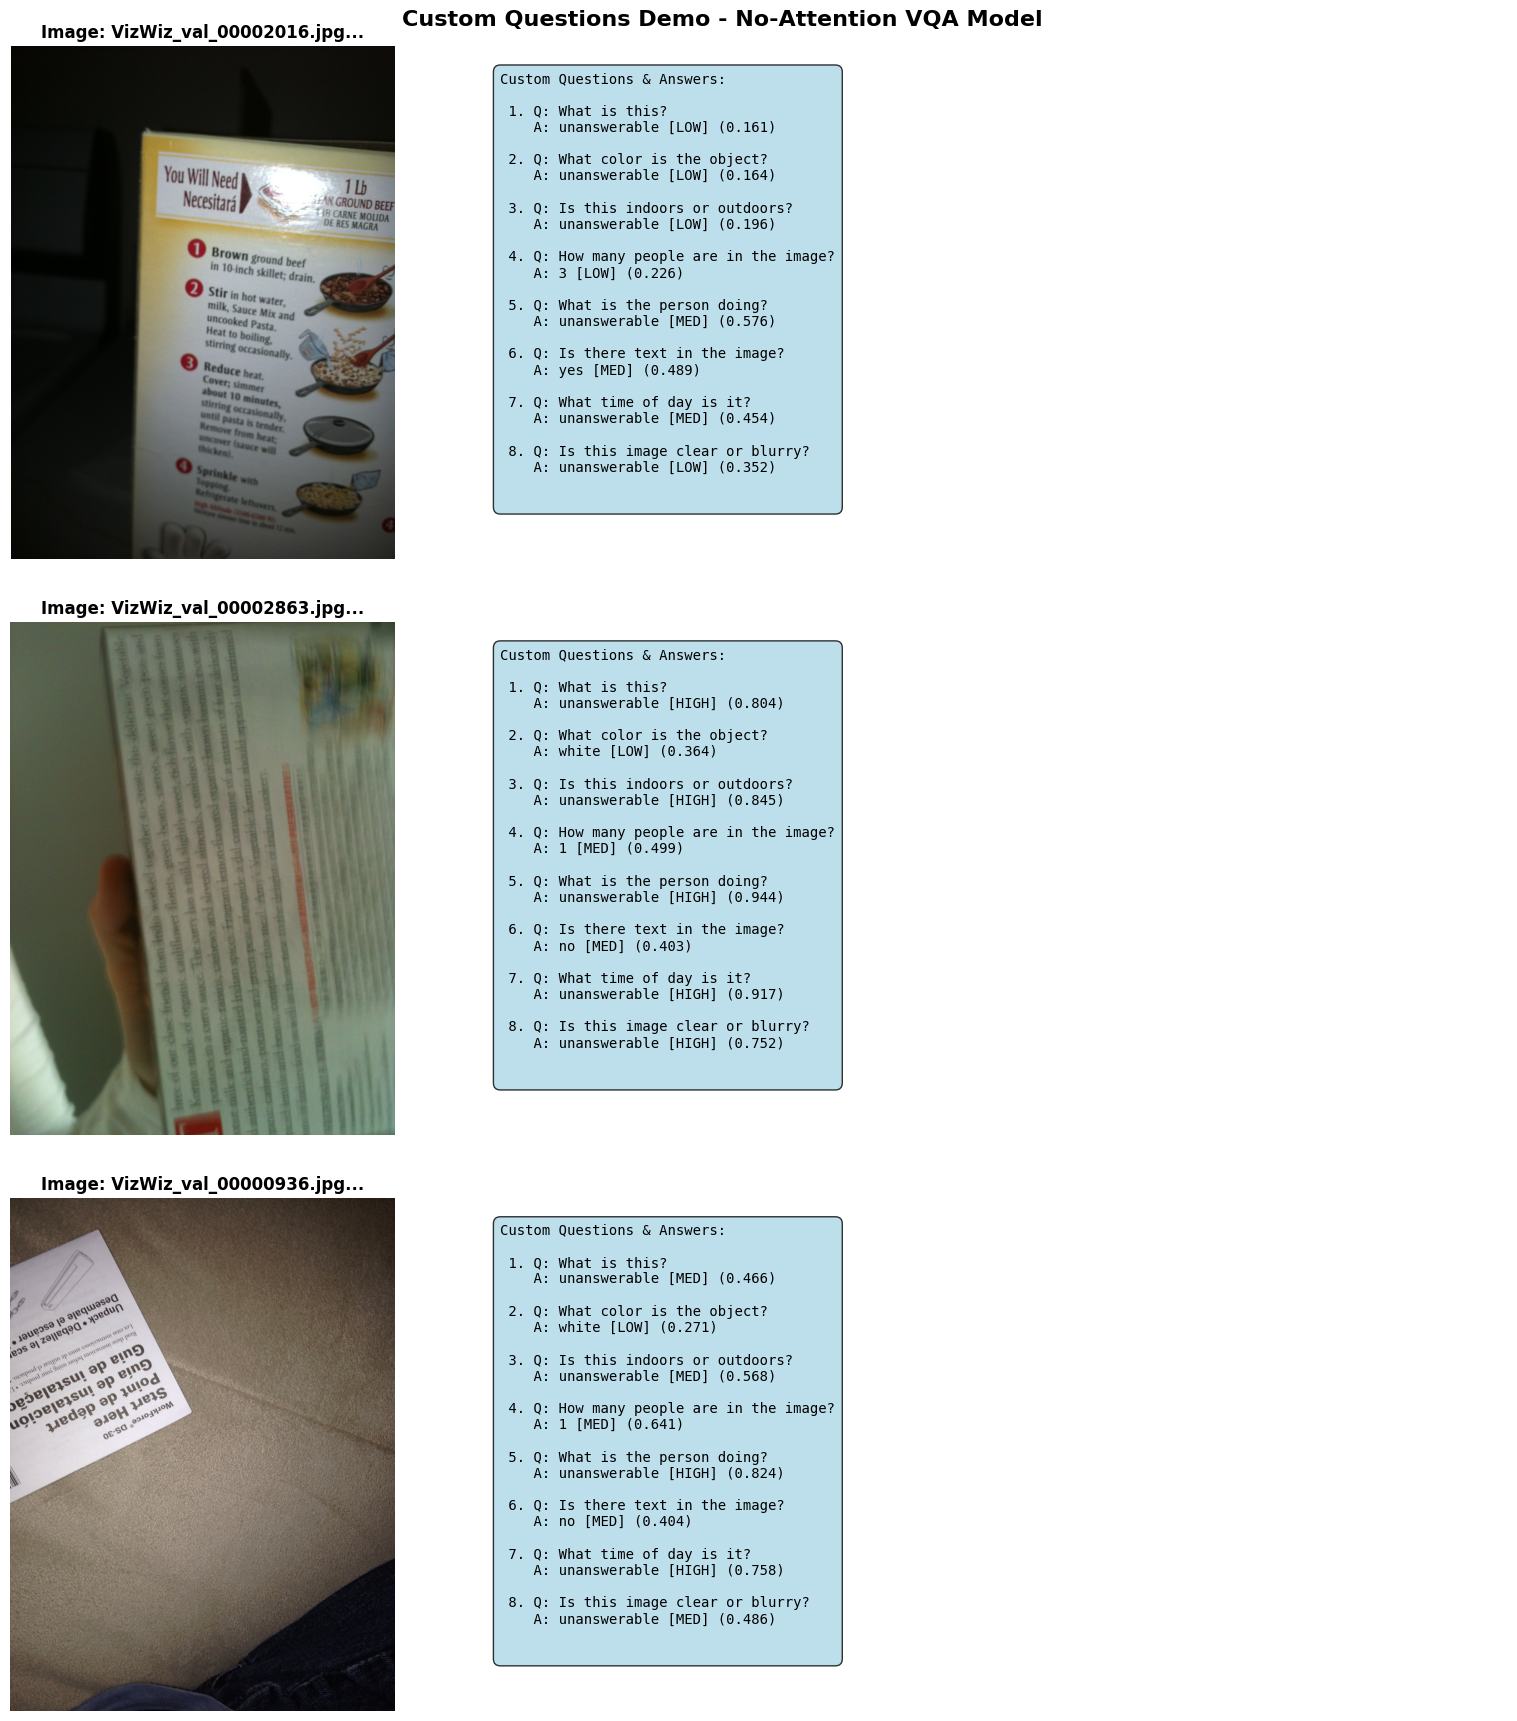

Custom questions demo saved: custom_questions_demo.png
Custom demo results saved: custom_questions_results.json

Custom Questions Analysis:
  Overall confidence statistics:
    Mean: 0.524
    Std:  0.237
    Min:  0.161
    Max:  0.944

  Best performing questions (avg confidence):
    1. "What is the person doing?": 0.781
    2. "What time of day is it?": 0.710
    3. "Is this indoors or outdoors?": 0.536
    4. "Is this image clear or blurry?": 0.530
    5. "What is this?": 0.477

Custom questions demo completed!


In [22]:
# Interactive demo with custom questions on selected images
print("Custom Questions Demo - No-Attention VQA Model")
print("=" * 55)

# Function to convert question text to model input
def preprocess_custom_question(question_text, question_vocab, max_length=26):
    """Convert question text to tensor format for model input"""
    # Tokenize question (simple word splitting)
    tokens = question_text.lower().strip().split()
    
    # Convert to indices
    indices = []
    for token in tokens:
        if token in question_vocab:
            indices.append(question_vocab[token])
        elif '<unk>' in question_vocab:
            indices.append(question_vocab['<unk>'])
        # Skip unknown tokens if no <unk> available
    
    # Pad or truncate to max_length
    if len(indices) < max_length:
        indices.extend([0] * (max_length - len(indices)))  # Pad with 0
    else:
        indices = indices[:max_length]  # Truncate
    
    # Calculate actual length (non-zero tokens)
    actual_length = len([i for i in indices if i != 0])
    
    return torch.tensor(indices), actual_length

# Function to get visual features for an image from dataset
def get_visual_features_by_name(img_name, dataset):
    """Find and return visual features for a specific image"""
    for i in range(len(dataset)):
        try:
            sample = dataset[i]
            sample_img_name = sample['img_name']
            
            if isinstance(sample_img_name, bytes):
                sample_img_name = sample_img_name.decode('utf-8')
            
            if sample_img_name == img_name:
                return sample['visual']
        except Exception:
            continue
    return None

# Function to ask custom question about an image
def ask_custom_question(model, img_name, question_text, dataset, question_vocab, answer_vocab, device):
    """Ask a custom question about a specific image"""
    # Get visual features
    visual_features = get_visual_features_by_name(img_name, dataset)
    if visual_features is None:
        return None
    
    # Preprocess question
    question_tensor, q_length = preprocess_custom_question(question_text, question_vocab)
    
    # Add batch dimension and move to device
    visual_batch = visual_features.unsqueeze(0)
    question_batch = question_tensor.unsqueeze(0) 
    q_length_batch = torch.tensor([q_length])
    
    if torch.cuda.is_available():
        visual_batch = visual_batch.cuda()
        question_batch = question_batch.cuda()
        q_length_batch = q_length_batch.cuda()
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        output = model(visual_batch, question_batch, q_length_batch)
        probs = torch.softmax(output, dim=1)
        
        # Get top-5 predictions
        top5_probs, top5_indices = torch.topk(probs, k=5, dim=1)
        
        # Convert to answers
        predictions = []
        for i in range(5):
            idx = top5_indices[0][i].item()
            answer = idx_to_answer.get(idx, '<unknown>')
            confidence = top5_probs[0][i].item()
            predictions.append({
                'answer': answer,
                'confidence': confidence
            })
    
    return {
        'question': question_text,
        'image': img_name,
        'predictions': predictions
    }

# Select images for custom question demo
if sample_results:
    demo_images = [result['img_name'] for result in sample_results[:3]]
else:
    # Fallback: try to get some image names from dataset
    demo_images = []
    for i in range(min(3, len(dataset_to_use))):
        try:
            sample = dataset_to_use[i]
            img_name = sample['img_name']
            if isinstance(img_name, bytes):
                img_name = img_name.decode('utf-8')
            demo_images.append(img_name)
        except:
            continue

print(f"Selected {len(demo_images)} images for custom question demo:")
for i, img_name in enumerate(demo_images, 1):
    print(f"  {i}. {img_name}")

# Define a variety of custom questions to test the model
custom_questions = [
    "What is this?",
    "What color is the object?",
    "Is this indoors or outdoors?",
    "How many people are in the image?",
    "What is the person doing?",
    "Is there text in the image?",
    "What time of day is it?",
    "Is this image clear or blurry?"
]

print(f"\nCustom questions to test ({len(custom_questions)}):")
for i, question in enumerate(custom_questions, 1):
    print(f"  {i}. {question}")

# Run custom question demo
if demo_images and len(demo_images) > 0:
    print(f"\nRunning custom question demo...")
    
    demo_results = []
    
    for img_name in demo_images:
        print(f"\nTesting image: {img_name}")
        print("=" * 40)
        
        img_results = {
            'image': img_name,
            'qa_pairs': []
        }
        
        # Test each question on this image
        for question in custom_questions:
            result = ask_custom_question(
                model, img_name, question, dataset_to_use,
                loaded_vocabs['question'], loaded_vocabs['answer'], device
            )
            
            if result:
                top_answer = result['predictions'][0]
                confidence = top_answer['confidence']
                answer = top_answer['answer']
                
                # Display result with confidence indicators
                if confidence > 0.7:
                    conf_indicator = "[HIGH]"
                elif confidence > 0.4:
                    conf_indicator = "[MED]"
                else:
                    conf_indicator = "[LOW]"
                
                print(f"  Q: {question}")
                print(f"  A: {answer} ({confidence:.3f}) {conf_indicator}")
                
                # Store top 3 predictions
                img_results['qa_pairs'].append({
                    'question': question,
                    'top_answer': answer,
                    'confidence': confidence,
                    'top_3_predictions': result['predictions'][:3]
                })
                print()
        
        demo_results.append(img_results)
    
    # Create visualization of custom Q&A demo
    if demo_results:
        fig, axes = plt.subplots(len(demo_results), 1, figsize=(16, 6*len(demo_results)))
        if len(demo_results) == 1:
            axes = [axes]
        
        fig.suptitle('Custom Questions Demo - No-Attention VQA Model', 
                     fontsize=16, fontweight='bold')
        
        for i, img_result in enumerate(demo_results):
            # Load image for display
            img, img_path = load_image_for_display(img_result['image'], config)
            
            if img:
                # Create two-column layout for this image
                # Left: image, Right: Q&A results
                gs = fig.add_gridspec(len(demo_results), 2, width_ratios=[1, 2])
                
                # Image subplot
                ax_img = fig.add_subplot(gs[i, 0])
                ax_img.imshow(img)
                ax_img.axis('off')
                ax_img.set_title(f"Image: {img_result['image'][:30]}...", fontweight='bold')
                
                # Q&A text subplot
                ax_text = fig.add_subplot(gs[i, 1])
                ax_text.axis('off')
                
                # Create Q&A text
                qa_text = "Custom Questions & Answers:\n\n"
                for j, qa in enumerate(img_result['qa_pairs'], 1):
                    confidence = qa['confidence']
                    conf_level = "HIGH" if confidence > 0.7 else "MED" if confidence > 0.4 else "LOW"
                    
                    qa_text += f"{j:2d}. Q: {qa['question']}\n"
                    qa_text += f"    A: {qa['top_answer']} [{conf_level}] ({confidence:.3f})\n\n"
                
                ax_text.text(0.05, 0.95, qa_text, transform=ax_text.transAxes,
                           fontsize=10, verticalalignment='top', fontfamily='monospace',
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
        
        # Remove original axes that are not used
        for ax in axes:
            ax.remove()
        
        plt.tight_layout()
        
        # Save custom demo visualization
        custom_demo_path = os.path.join(log_dir_run, 'custom_questions_demo.png')
        plt.savefig(custom_demo_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Custom questions demo saved: {os.path.basename(custom_demo_path)}")
        
        # Save detailed demo results
        demo_results_file = os.path.join(log_dir_run, 'custom_questions_results.json')
        with open(demo_results_file, 'w') as f:
            json.dump(demo_results, f, indent=2)
        
        print(f"Custom demo results saved: {os.path.basename(demo_results_file)}")
        
        # Analysis of custom questions performance
        print(f"\nCustom Questions Analysis:")
        
        all_confidences = []
        question_performance = {}
        
        for img_result in demo_results:
            for qa in img_result['qa_pairs']:
                question = qa['question']
                confidence = qa['confidence']
                
                all_confidences.append(confidence)
                
                if question not in question_performance:
                    question_performance[question] = []
                question_performance[question].append(confidence)
        
        print(f"  Overall confidence statistics:")
        print(f"    Mean: {np.mean(all_confidences):.3f}")
        print(f"    Std:  {np.std(all_confidences):.3f}")
        print(f"    Min:  {np.min(all_confidences):.3f}")
        print(f"    Max:  {np.max(all_confidences):.3f}")
        
        print(f"\n  Best performing questions (avg confidence):")
        avg_confidences = {q: np.mean(confs) for q, confs in question_performance.items()}
        sorted_questions = sorted(avg_confidences.items(), key=lambda x: x[1], reverse=True)
        
        for i, (question, avg_conf) in enumerate(sorted_questions[:5], 1):
            print(f"    {i}. \"{question}\": {avg_conf:.3f}")
    
    else:
        print("ERROR: No demo results generated")

else:
    print("ERROR: No images available for custom question demo")

print(f"\n" + "=" * 55)
print("Custom questions demo completed!")
print("=" * 55)

## 14. URL-based VQA Testing Interface

URL-based VQA Testing Interface
URL-based VQA interface ready!

Demo: URL-based VQA Testing
Demo URL: https://images.unsplash.com/photo-1517849845537-4d257902454a?w=500
Demo questions: 4
  1. What animal is this?
  2. What color is the dog?
  3. Is this indoors or outdoors?
  4. What is the dog doing?

Running URL-based VQA demo...
Loading image from URL...
Image loaded successfully! Size: (500, 667)
Extracting visual features...
Image loaded successfully! Size: (500, 667)
Extracting visual features...
Visual features extracted! Shape: torch.Size([1, 2048])

Processing 4 questions...

1. What animal is this?
   Answer: dog (0.217) [LOW]

2. What color is the dog?
   Answer: red (0.202) [LOW]

3. Is this indoors or outdoors?
   Answer: unanswerable (0.279) [LOW]

4. What is the dog doing?
   Answer: unanswerable (0.055) [LOW]

Demo completed successfully!

Demo Results Summary:
  1. What animal is this?
     → dog [LOW] (0.217)
  2. What color is the dog?
     → red [LOW] (0.202)
  3. I

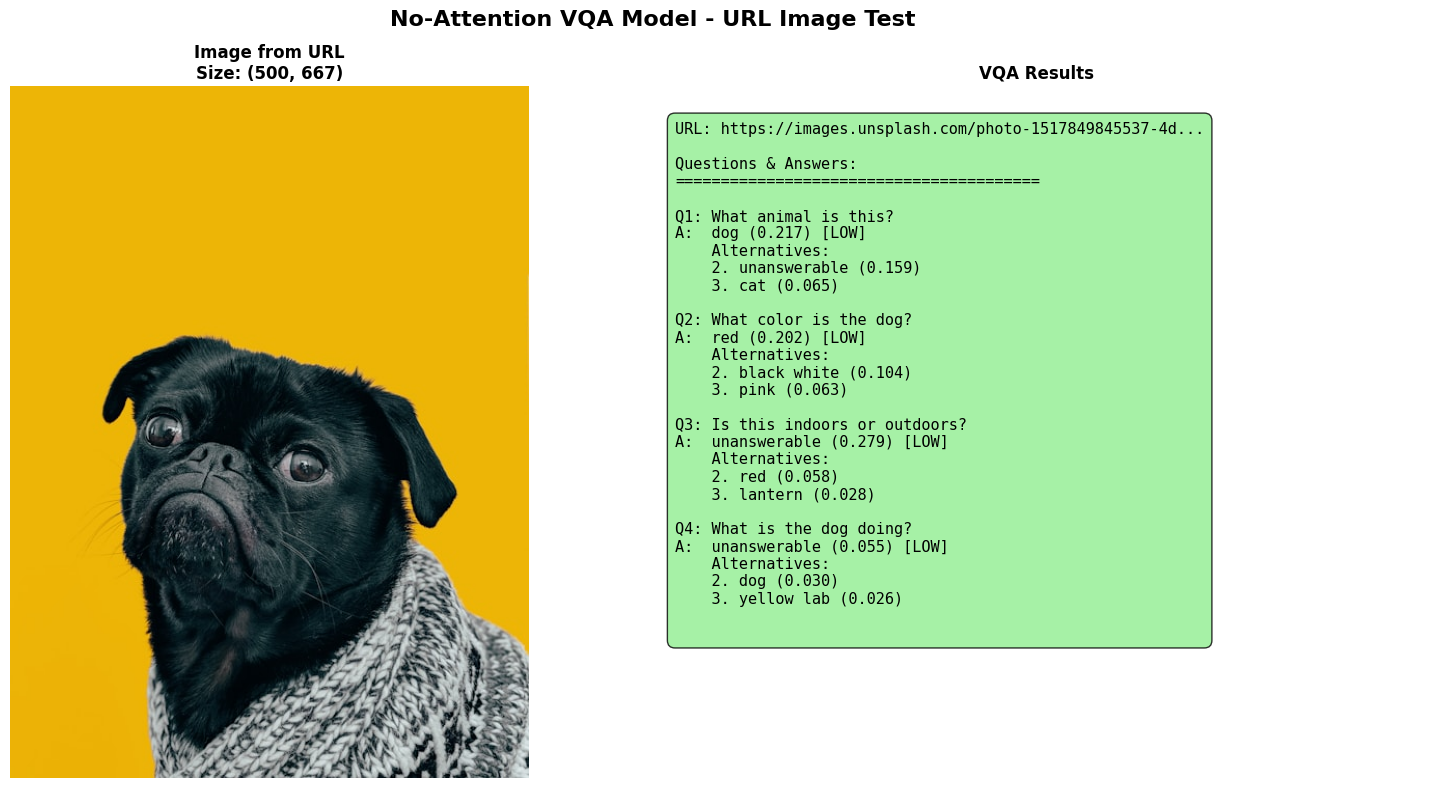

URL demo results saved: url_demo_results.json

CUSTOM USAGE INSTRUCTIONS

To test with your own images and questions:

1. Replace demo_url with your image URL
2. Replace demo_questions with your questions
3. Run the vqa_from_url_noattention function

Example:
```python
custom_url = "https://your-image-url.com/image.jpg"
custom_questions = ["Your question here?"]

results = vqa_from_url_noattention(
    image_url=custom_url,
    questions=custom_questions,
    model=model,
    question_vocab=loaded_vocabs['question'],
    answer_vocab=idx_to_answer,
    device=device
)

if results:
    visualize_url_results(results)
```

Supported question types:
- Object identification: "What is this?"
- Color questions: "What color is...?"
- Location: "Where is...?"
- Count: "How many...?"
- Yes/No questions: "Is there...?"
- Action: "What is happening?"

URL-based VQA interface setup completed!


In [24]:
# URL-based VQA Testing Interface for No-Attention Model
print("URL-based VQA Testing Interface")
print("=" * 50)

import requests
from io import BytesIO
import torchvision.transforms as transforms
import torchvision.models as models

# Create ResNet feature extractor for URL images
class URLFeatureExtractor(nn.Module):
    """Extract visual features from URL images for No-Attention model"""
    
    def __init__(self, device):
        super(URLFeatureExtractor, self).__init__()
        # Use ResNet-152 to match training features
        self.resnet = models.resnet152(pretrained=True)
        
        # Remove the final classification layers
        self.features = nn.Sequential(*list(self.resnet.children())[:-2])
        
        # Global average pooling to get 2048-dim features (no attention)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.features.eval()
        self.global_pool.eval()
        
    def forward(self, x):
        # Extract features
        features = self.features(x)  # [batch, 2048, 14, 14]
        
        # Global average pooling for no-attention
        pooled = self.global_pool(features)  # [batch, 2048, 1, 1]
        pooled = pooled.view(pooled.size(0), -1)  # [batch, 2048]
        
        return pooled

# Image preprocessing for URL images
def preprocess_url_image(image):
    """Preprocess image for ResNet feature extraction"""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    return transform(image)

# VQA function for URL images
def vqa_from_url_noattention(image_url, questions, model, question_vocab, answer_vocab, device):
    """
    Perform VQA on image from URL using No-Attention model
    
    Args:
        image_url: URL of the image
        questions: List of questions to ask
        model: Trained No-Attention VQA model
        question_vocab: Question vocabulary
        answer_vocab: Answer vocabulary (idx_to_answer mapping)
        device: PyTorch device
    
    Returns:
        Dictionary with results
    """
    try:
        print(f"Loading image from URL...")
        
        # Download image
        response = requests.get(image_url, timeout=10)
        response.raise_for_status()
        
        # Load image
        img = Image.open(BytesIO(response.content)).convert('RGB')
        print(f"Image loaded successfully! Size: {img.size}")
        
        # Extract visual features
        print(f"Extracting visual features...")
        feature_extractor = URLFeatureExtractor(device).to(device)
        
        # Preprocess image
        img_tensor = preprocess_url_image(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            visual_features = feature_extractor(img_tensor)
        
        print(f"Visual features extracted! Shape: {visual_features.shape}")
        
        # Process questions
        results = {
            'image_url': image_url,
            'image': img,
            'image_size': img.size,
            'predictions': []
        }
        
        model.eval()
        print(f"\nProcessing {len(questions)} questions...")
        
        with torch.no_grad():
            for i, question in enumerate(questions, 1):
                print(f"\n{i}. {question}")
                
                # Preprocess question
                question_tensor, q_length = preprocess_custom_question(
                    question, question_vocab, max_length=26
                )
                
                # Add batch dimension and move to device
                question_batch = question_tensor.unsqueeze(0).to(device)
                q_length_batch = torch.tensor([q_length]).to(device)
                
                # Forward pass
                output = model(visual_features, question_batch, q_length_batch)
                probs = torch.softmax(output, dim=1)
                
                # Get top-3 predictions
                top3_probs, top3_indices = torch.topk(probs, k=3, dim=1)
                
                # Convert to answers
                predictions = []
                for j in range(3):
                    idx = top3_indices[0][j].item()
                    answer = answer_vocab.get(idx, '<unknown>')
                    confidence = top3_probs[0][j].item()
                    predictions.append({
                        'answer': answer,
                        'confidence': confidence
                    })
                
                # Display result
                top_answer = predictions[0]
                conf_level = "HIGH" if top_answer['confidence'] > 0.7 else "MED" if top_answer['confidence'] > 0.4 else "LOW"
                print(f"   Answer: {top_answer['answer']} ({top_answer['confidence']:.3f}) [{conf_level}]")
                
                results['predictions'].append({
                    'question': question,
                    'answer': top_answer['answer'],
                    'confidence': top_answer['confidence'],
                    'alternatives': predictions[1:]
                })
        
        return results
        
    except requests.RequestException as e:
        print(f"ERROR: Error downloading image: {e}")
        return None
    except Exception as e:
        print(f"ERROR: Error in VQA processing: {e}")
        return None

# Visualization function for URL results
def visualize_url_results(results):
    """Visualize VQA results from URL"""
    if not results:
        print("ERROR: No results to visualize")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('No-Attention VQA Model - URL Image Test', fontsize=16, fontweight='bold')
    
    # Display image
    ax1.imshow(results['image'])
    ax1.axis('off')
    ax1.set_title(f"Image from URL\nSize: {results['image_size']}", fontweight='bold')
    
    # Display Q&A results
    qa_text = f"URL: {results['image_url'][:50]}...\n\n"
    qa_text += "Questions & Answers:\n" + "="*40 + "\n\n"
    
    for i, pred in enumerate(results['predictions'], 1):
        confidence = pred['confidence']
        conf_level = "HIGH" if confidence > 0.7 else "MED" if confidence > 0.4 else "LOW"
        
        qa_text += f"Q{i}: {pred['question']}\n"
        qa_text += f"A:  {pred['answer']} ({confidence:.3f}) [{conf_level}]\n"
        
        # Show alternatives
        if pred['alternatives']:
            qa_text += "    Alternatives:\n"
            for j, alt in enumerate(pred['alternatives'], 2):
                qa_text += f"    {j}. {alt['answer']} ({alt['confidence']:.3f})\n"
        qa_text += "\n"
    
    ax2.text(0.05, 0.95, qa_text, transform=ax2.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')
    ax2.set_title("VQA Results", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("URL-based VQA interface ready!")

# Demo with sample URL and questions
print(f"\nDemo: URL-based VQA Testing")
print("=" * 40)

# Sample image URL and questions for testing
demo_url = "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=500"
demo_questions = [
    "What animal is this?",
    "What color is the dog?",
    "Is this indoors or outdoors?",
    "What is the dog doing?"
]

print(f"Demo URL: {demo_url}")
print(f"Demo questions: {len(demo_questions)}")
for i, q in enumerate(demo_questions, 1):
    print(f"  {i}. {q}")

# Run demo
print(f"\nRunning URL-based VQA demo...")

demo_results = vqa_from_url_noattention(
    image_url=demo_url,
    questions=demo_questions,
    model=model,
    question_vocab=loaded_vocabs['question'],
    answer_vocab=idx_to_answer,
    device=device
)

if demo_results:
    print(f"\nDemo completed successfully!")
    
    # Show summary
    print(f"\nDemo Results Summary:")
    for i, pred in enumerate(demo_results['predictions'], 1):
        conf_status = "[HIGH]" if pred['confidence'] > 0.7 else "[MED]" if pred['confidence'] > 0.4 else "[LOW]"
        print(f"  {i}. {pred['question']}")
        print(f"     → {pred['answer']} {conf_status} ({pred['confidence']:.3f})")
    
    # Visualize results
    print(f"\nCreating visualization...")
    visualize_url_results(demo_results)
    
    # Save demo results
    url_demo_file = os.path.join(log_dir_run, 'url_demo_results.json')
    
    # Prepare data for saving (can't serialize PIL Image)
    save_data = {
        'image_url': demo_results['image_url'],
        'image_size': demo_results['image_size'],
        'predictions': demo_results['predictions'],
        'demo_timestamp': datetime.now().isoformat()
    }
    
    with open(url_demo_file, 'w') as f:
        json.dump(save_data, f, indent=2)
    
    print(f"URL demo results saved: {os.path.basename(url_demo_file)}")
    
else:
    print("ERROR: Demo failed")

# Instructions for custom usage
print(f"\n" + "=" * 50)
print("CUSTOM USAGE INSTRUCTIONS")
print("=" * 50)
print("""
To test with your own images and questions:

1. Replace demo_url with your image URL
2. Replace demo_questions with your questions
3. Run the vqa_from_url_noattention function

Example:
```python
custom_url = "https://your-image-url.com/image.jpg"
custom_questions = ["Your question here?"]

results = vqa_from_url_noattention(
    image_url=custom_url,
    questions=custom_questions,
    model=model,
    question_vocab=loaded_vocabs['question'],
    answer_vocab=idx_to_answer,
    device=device
)

if results:
    visualize_url_results(results)
```

Supported question types:
- Object identification: "What is this?"
- Color questions: "What color is...?"
- Location: "Where is...?"
- Count: "How many...?"
- Yes/No questions: "Is there...?"
- Action: "What is happening?"
""")

print("URL-based VQA interface setup completed!")
print("=" * 50)